# 1. SETUP

##1.1 Mount Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Academic/CSCI 567/Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
%cd "$PROJECT_DIR"

Mounted at /content/drive
/content/drive/MyDrive/Academic/CSCI 567/Project


##1.2 Repo Cloning

In [ ]:
import os
REPO_DIR = '/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/AbhinavSurendra/Full-Press-ML.git "$REPO_DIR"
else:
    %cd "$REPO_DIR"
    !git pull

%cd "$REPO_DIR"
!ls

/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
Already up to date.
/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
'567 Initial Project Presentation.pdf'	 PIPELINE_OVERVIEW.md   scripts
'567 Project Proposal.pdf'		 PROJECT_PLAN.md        src
 configs				 pyproject.toml         tasks
 data					 README.md	        tests
 DATA_SCHEMA_AND_JOIN.md		 REPORT.md


##1.3 Dependecy Install

In [ ]:
%cd /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML
!pip install -q -e ".[dev]"
!pip install -q py7zr

/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 19.6 MB/s eta 0:00:00
  Building editable for full-press-ml (pyproject.toml) ... done


##1.4 Sanity Check GPU setup

In [ ]:
import sys, torch
print("python:", sys.version.split()[0])
print("torch :", torch.__version__)
print("cuda  :", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

python: 3.12.13
torch : 2.10.0+cu128
cuda  : True NVIDIA A100-SXM4-40GB


##1.5 Download Tiny Dataset and Run Once

In [ ]:
%cd /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML

import os
RAW_DIR = 'data/raw/tiny'
if not os.path.exists(f'{RAW_DIR}/manifest.json'):
    !python scripts/download_tiny_dataset.py --config tiny --output-dir "$RAW_DIR"
else:
    print("tiny dataset already present, skipping download")

!ls -la "$RAW_DIR"

/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
downloaded 12.11.2015.MIA.at.IND
downloaded 2016.NBA.Raw.SportVU.Game.Logs12.05.2015.CHA.at.CHI
downloaded 11.27.2015.MIA.at.NYK
downloaded 11.11.2015.TOR.at.PHI
downloaded 01.22.2016.LAC.at.NYK
wrote manifest to data/raw/tiny/manifest.json
total 92369
-rw------- 1 root root 94575383 Apr 17 22:06 2015-16_pbp.csv
drwx------ 2 root root     4096 Apr 17 22:06 archives
drwx------ 7 root root     4096 Apr 17 22:06 games
-rw------- 1 root root     1389 Apr 17 22:06 manifest.json


##1.6 Build the processed event/frame/possession tables

In [ ]:
%cd /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML

!python scripts/build_possessions.py \
    --games-dir data/raw/tiny/games \
    --pbp data/raw/tiny/2015-16_pbp.csv \
    --output-dir data/processed/standard

!cat data/processed/standard/audit_summary.json

/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
{
  "events": 2247,
  "frames": 996784,
  "games": 5,
  "invalid_frames": 3217,
  "matched_events": 2219,
  "possessions": 995,
  "unmatched_events": 28,
  "usable_label_counts": {
    "free_throws": 107,
    "made_2": 290,
    "made_3": 70,
    "missed_shot": 352,
    "turnover": 124
  },
  "usable_possessions": 943,
  "usable_split_counts": {
    "test": 198,
    "train": 563,
    "val": 182
  },
  "valid_frames": 993567
}

##1.7 stage processed CSVs to fast local disk

In [ ]:
!mkdir -p /content/work/processed
!cp /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML/data/processed/standard/*.csv /content/work/processed/
!cp /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML/data/processed/standard/audit_summary.json /content/work/processed/
!ls -lh /content/work/processed

total 235M
-rw------- 1 root root  428 Apr 17 22:08 audit_summary.json
-rw------- 1 root root 224K Apr 17 22:08 events.csv
-rw------- 1 root root 234M Apr 17 22:08 frames.csv
-rw------- 1 root root 120K Apr 17 22:08 possessions.csv


#1.8 First Experiement XGBoost

In [ ]:
%cd /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML

!python scripts/train_baseline.py \
    --data /content/work/processed/frames.csv \
    --label-column terminal_label \
    --model xgboost \
    --aggregate-frames

/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
train_rows=563 eval_rows=198 eval_split=test
accuracy=0.5657
              precision    recall  f1-score   support

 free_throws       0.60      0.35      0.44        17
      made_2       0.55      0.62      0.58        60
      made_3       0.25      0.09      0.13        11
 missed_shot       0.60      0.78      0.68        79
    turnover       0.46      0.19      0.27        31

    accuracy                           0.57       198
   macro avg       0.49      0.41      0.42       198
weighted avg       0.54      0.57      0.54       198



##1.9 Second Experiment LSTM

In [ ]:
%cd /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML

import os, torch, numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch.utils.data import DataLoader

import sys
SRC = '/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src'
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from full_press_ml.data.tracking_dataset import PossessionSequenceDataset
from full_press_ml.models.lstm_model import PossessionLSTM
from full_press_ml.training.train_lstm import train_epoch, evaluate

torch.manual_seed(0); np.random.seed(0)

FRAMES = '/content/work/processed/frames.csv'
CKPT_DIR = Path('/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/artifacts')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FRAMES)
df = df[df.get('possession_is_usable', 1) == 1]
df = df[df['possession_id'].notna()].copy()

le = LabelEncoder()
df['label_id'] = le.fit_transform(df['terminal_label'])

drop = {'game_id','event_id','possession_id','frame_idx','possession_frame_idx',
        'split','terminal_label','pbp_join_status','label_id'}
feat_cols = [c for c in df.columns if c not in drop and pd.api.types.is_numeric_dtype(df[c])]
df[feat_cols] = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)

train_df = df[df['split']=='train']; eval_df = df[df['split']=='test']
train_ds = PossessionSequenceDataset(train_df, feat_cols, 'label_id', max_len=100)
eval_ds  = PossessionSequenceDataset(eval_df,  feat_cols, 'label_id', max_len=100)
train_ld = DataLoader(train_ds, batch_size=64, shuffle=True)
eval_ld  = DataLoader(eval_ds,  batch_size=64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PossessionLSTM(len(feat_cols), 128, 2, int(df['label_id'].nunique())).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(10):
    loss = train_epoch(model, train_ld, opt, crit, device)
    print(f"epoch={epoch+1} loss={loss:.4f}")

preds, y = evaluate(model, eval_ld, device)
print("accuracy:", accuracy_score(y, preds))
print(classification_report(y, preds, target_names=le.classes_, zero_division=0))

torch.save({
    'state_dict': model.state_dict(),
    'feature_columns': feat_cols,
    'label_classes': le.classes_.tolist(),
}, CKPT_DIR / 'lstm_tiny.pt')
print("saved:", CKPT_DIR / 'lstm_tiny.pt')

/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
epoch=1 loss=1.4905
epoch=2 loss=1.4599
epoch=3 loss=1.4416
epoch=4 loss=1.4396
epoch=5 loss=1.4360
epoch=6 loss=1.4280
epoch=7 loss=1.4182
epoch=8 loss=1.4195
epoch=9 loss=1.4100
epoch=10 loss=1.4060
accuracy: 0.3939393939393939
              precision    recall  f1-score   support

 free_throws       0.00      0.00      0.00        17
      made_2       0.20      0.02      0.03        60
      made_3       0.00      0.00      0.00        11
 missed_shot       0.40      0.97      0.57        79
    turnover       0.00      0.00      0.00        31

    accuracy                           0.39       198
   macro avg       0.12      0.20      0.12       198
weighted avg       0.22      0.39      0.24       198

saved: /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/artifacts/lstm_tiny.pt


##1.10 Future Sessions: JUST START FROM HERE

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
%cd /content/drive/MyDrive/Academic/CSCI\ 567/Project/Full-Press-ML
!pip install -q -e ".[dev]" && !pip install -q py7zr
!mkdir -p /content/work/processed && cp data/processed/standard/*.csv /content/work/processed/

Mounted at /content/drive
/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.3 MB/s eta 0:00:00
  Building editable for full-press-ml (pyproject.toml) ... done
/bin/bash: line 1: !pip: command not found


# 0.0 Terminal Cell

In [ ]:
import sys
SRC = '/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src'
if SRC not in sys.path: sys.path.insert(0, SRC)

# pull the listing via the same code the downloader uses
import importlib.util, pathlib
spec = importlib.util.spec_from_file_location(
    "dl", "/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/scripts/download_tiny_dataset.py"
)
dl = importlib.util.module_from_spec(spec); spec.loader.exec_module(dl)

items = dl.fetch_listing_items()
print(f"total games available upstream: {len(items)}")
print("first 3:", [i['name'] for i in items[:3]])

total games available upstream: 636
first 3: ['01.01.2016.CHA.at.TOR.7z', '01.01.2016.DAL.at.MIA.7z', '01.01.2016.NYK.at.CHI.7z']


#2.1 Improving XGBoost

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=False)

import os, sys
REPO_DIR   = '/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML'
ARCHIVE_DIR = f'{REPO_DIR}/data/raw/medium/archives'   # on Drive (cached)
PBP_PATH    = f'{REPO_DIR}/data/raw/medium/2015-16_pbp.csv'
MANIFEST    = f'{REPO_DIR}/data/raw/medium/manifest.json'
LOCAL_GAMES = '/content/work/medium/games'              # local disk, ephemeral
PROC_DIR    = f'{REPO_DIR}/data/processed/medium_standard'  # on Drive

os.makedirs(ARCHIVE_DIR, exist_ok=True)
os.makedirs(LOCAL_GAMES, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

SRC = f'{REPO_DIR}/src'
if SRC not in sys.path: sys.path.insert(0, SRC)

os.chdir(REPO_DIR)
!pip install -q py7zr

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download 100 archives to drive

In [ ]:
import json, random, urllib.request, shutil
from pathlib import Path
import py7zr

TRACKING_INDEX_URL = (
    "https://github.com/linouk23/NBA-Player-Movements/"
    "raw/master/data/2016.NBA.Raw.SportVU.Game.Logs"
)
PBP_URL = ("https://github.com/sumitrodatta/nba-alt-awards/"
           "raw/main/Historical/PBP%20Data/2015-16_pbp.csv")

# reuse the upstream script's listing parser — deterministic with seed=9
import importlib.util
spec = importlib.util.spec_from_file_location(
    "dl", f"{REPO_DIR}/scripts/download_tiny_dataset.py")
dl = importlib.util.module_from_spec(spec); spec.loader.exec_module(dl)

items = dl.fetch_listing_items()
random.seed(9)
selected = random.sample(items, 100)
print(f"selected {len(selected)} games")

# PBP CSV (small, stays on Drive)
if not Path(PBP_PATH).exists():
    print("downloading play-by-play CSV...")
    with urllib.request.urlopen(PBP_URL) as r, open(PBP_PATH, 'wb') as f:
        shutil.copyfileobj(r, f)

# archives → Drive (cached); extracted JSON → /content (ephemeral)
manifest = []
for i, game in enumerate(selected, 1):
    name = game['name'][:-3]
    archive_path = Path(ARCHIVE_DIR) / f"{name}.7z"
    extract_dir  = Path(LOCAL_GAMES) / name

    if not archive_path.exists():
        url = f"{TRACKING_INDEX_URL}/{name}.7z"
        with urllib.request.urlopen(url) as r, open(archive_path, 'wb') as f:
            shutil.copyfileobj(r, f)

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with py7zr.SevenZipFile(archive_path, mode='r') as z:
            z.extractall(path=extract_dir)

    manifest.append({'game_name': name,
                     'archive_path': str(archive_path),
                     'extract_dir': str(extract_dir)})
    if i % 10 == 0: print(f"  {i}/100 done")

with open(MANIFEST, 'w') as f:
    json.dump({'config': 'medium', 'num_games': len(manifest),
               'games': manifest, 'pbp_path': PBP_PATH}, f, indent=2)

!du -sh "$ARCHIVE_DIR" "$LOCAL_GAMES"

selected 100 games
downloading play-by-play CSV...
  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
557M	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/raw/medium/archives
9.3G	/content/work/medium/games


##build processed tables

In [ ]:
!python scripts/build_possessions.py \
    --games-dir "$LOCAL_GAMES" \
    --pbp "$PBP_PATH" \
    --output-dir "$PROC_DIR"

!cat "$PROC_DIR/audit_summary.json"
!du -sh "$PROC_DIR"/*

{
  "events": 46609,
  "frames": 19985119,
  "games": 100,
  "invalid_frames": 90413,
  "matched_events": 46006,
  "possessions": 19967,
  "unmatched_events": 603,
  "usable_label_counts": {
    "free_throws": 2299,
    "made_2": 5524,
    "made_3": 1595,
    "missed_shot": 6334,
    "turnover": 2704
  },
  "usable_possessions": 18456,
  "usable_split_counts": {
    "test": 3471,
    "train": 11144,
    "val": 3841
  },
  "valid_frames": 19894706
}512	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/medium_standard/audit_summary.json
4.6M	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/medium_standard/events.csv
4.6G	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/medium_standard/frames.csv
2.4M	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/medium_standard/possessions.csv


##Extract Posession Level Features

In [ ]:
import pandas as pd
from full_press_ml.features.engineer import build_frame_aggregate_table

FEATS_PATH = f'{PROC_DIR}/possession_features.csv'

if not os.path.exists(FEATS_PATH):
    # dtype hints keep memory manageable when reading the big frames table
    numeric32 = ['game_clock','shot_clock','ball_x','ball_y','ball_z',
                 'offense_centroid_x','offense_centroid_y',
                 'offense_mean_radius','offense_mean_distance_to_ball',
                 'defense_centroid_x','defense_centroid_y',
                 'defense_mean_radius','defense_mean_distance_to_ball']
    dtype_hint = {c: 'float32' for c in numeric32}
    dtype_hint.update({'is_valid_frame':'int8', 'missing_shot_clock':'int8',
                       'player_count':'int8', 'offense_player_count':'int8',
                       'defense_player_count':'int8'})

    print("reading frames.csv ...")
    frames = pd.read_csv(f'{PROC_DIR}/frames.csv', dtype=dtype_hint,
                         low_memory=False)
    frames = frames[frames['possession_id'].notna()]
    if 'possession_is_usable' in frames.columns:
        frames = frames[frames['possession_is_usable'] == 1]
    print(f"  {len(frames):,} usable frame rows")

    print("aggregating ...")
    agg = build_frame_aggregate_table(frames)
    agg.to_csv(FEATS_PATH, index=False)
    del frames
    print(f"saved {FEATS_PATH} with {len(agg):,} possessions")
else:
    print(f"{FEATS_PATH} already built")

!du -sh "$FEATS_PATH"

reading frames.csv ...
  19,712,208 usable frame rows
aggregating ...
saved /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/medium_standard/possession_features.csv with 18,456 possessions
15M	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/medium_standard/possession_features.csv


## Train XGBoost on 100 games

In [ ]:
import pandas as pd, numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from full_press_ml.models.baselines import build_xgboost

agg = pd.read_csv(f'{PROC_DIR}/possession_features.csv')
agg = agg[agg['terminal_label'].notna()].copy()

train_df = agg[agg['split'].isin(['train', 'val'])].copy()
test_df  = agg[agg['split'] == 'test'].copy()
print(f"train: {len(train_df):,}  test: {len(test_df):,}")
print("test class balance:", test_df['terminal_label'].value_counts().to_dict())

drop = {'game_id','possession_id','split','event_ids','end_reason',
        'is_usable','possession_is_usable','terminal_label'}
feat_cols = [c for c in train_df.columns if c not in drop]

X_train = train_df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
X_test  = test_df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
le = LabelEncoder()
y_train = le.fit_transform(train_df['terminal_label'])
y_test  = le.transform(test_df['terminal_label'])

model = build_xgboost(num_classes=len(le.classes_))
sw = compute_sample_weight('balanced', y_train)   # fights majority-class bias
model.fit(X_train, y_train, sample_weight=sw)
pred = model.predict(X_test)

print(f"\naccuracy = {accuracy_score(y_test, pred):.4f}")
print(classification_report(y_test, pred, target_names=le.classes_, zero_division=0))
print("confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(y_test, pred),
                   index=le.classes_, columns=le.classes_))

train: 14,985  test: 3,471
test class balance: {'missed_shot': 1198, 'made_2': 1041, 'turnover': 510, 'free_throws': 404, 'made_3': 318}

accuracy = 0.6076
              precision    recall  f1-score   support

 free_throws       0.75      0.79      0.77       404
      made_2       0.60      0.56      0.58      1041
      made_3       0.39      0.45      0.42       318
 missed_shot       0.68      0.68      0.68      1198
    turnover       0.50      0.50      0.50       510

    accuracy                           0.61      3471
   macro avg       0.58      0.59      0.59      3471
weighted avg       0.61      0.61      0.61      3471

confusion matrix (rows=true, cols=pred):
             free_throws  made_2  made_3  missed_shot  turnover
free_throws          319      33       7           33        12
made_2                52     582     130          171       106
made_3                10      86     143           55        24
missed_shot           33     190      55          811     

# Experimenting with LSTM

##3.1 Pipeline Setup


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, sys, json
from pathlib import Path

REPO_DIR   = Path('/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML')
RAW_DIR    = REPO_DIR / 'data/raw/full'
ARCHIVE_DIR = RAW_DIR / 'archives'
PROC_DIR   = REPO_DIR / 'data/processed/full'
LOCAL_WORK = Path('/content/work/full')         # scratch for extraction, ephemeral
PBP_PATH   = RAW_DIR / '2015-16_pbp.csv'
MANIFEST   = RAW_DIR / 'manifest.json'
SPLIT_MAP  = PROC_DIR / 'split_map.json'

for p in (ARCHIVE_DIR, PROC_DIR, LOCAL_WORK, PROC_DIR / 'shards'):
    p.mkdir(parents=True, exist_ok=True)

# make the repo package importable
SRC = str(REPO_DIR / 'src')
if SRC not in sys.path: sys.path.insert(0, SRC)
os.chdir(REPO_DIR)

# deps
!pip install -q py7zr pyarrow tqdm

# sanity: A100 visible?
import torch
print("torch:", torch.__version__)
print("cuda :", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "(no GPU)")
print("\npaths:")
for k, v in [('REPO_DIR', REPO_DIR), ('ARCHIVE_DIR', ARCHIVE_DIR),
             ('PROC_DIR', PROC_DIR), ('LOCAL_WORK', LOCAL_WORK)]:
    print(f"  {k:12s} = {v}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.3 MB/s eta 0:00:00
torch: 2.10.0+cu128
cuda : True NVIDIA A100-SXM4-40GB

paths:
  REPO_DIR     = /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML
  ARCHIVE_DIR  = /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/raw/full/archives
  PROC_DIR     = /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/full
  LOCAL_WORK   = /content/work/full


###3.1.2 fetch the full 636-game listing, compute the global split

In [ ]:
import importlib.util, json, random
from full_press_ml.data.raw_loader import assign_game_splits

# reuse the upstream listing parser from the repo's download script
spec = importlib.util.spec_from_file_location(
    "dl", str(REPO_DIR / 'scripts/download_tiny_dataset.py'))
dl = importlib.util.module_from_spec(spec); spec.loader.exec_module(dl)

items = dl.fetch_listing_items()
# deterministic ordering: sort by name so shuffles are reproducible
items = sorted(items, key=lambda x: x['name'])
print(f"total games upstream: {len(items)}")
print("first 3:", [i['name'] for i in items[:3]])
print("last 3 :", [i['name'] for i in items[-3:]])

# extract integer game ids from archive names like '01.02.2016.DEN.at.GSW.7z'
# the actual game_id comes from the JSON itself (10-digit '00215...'), which we
# don't know until extraction. so we build the split map from archive names
# as a stable surrogate key for now, and reconcile to real game_ids when we
# start extracting in Phase 1C.

archive_names = [item['name'][:-3] for item in items]   # strip '.7z'
archive_names_sorted = sorted(archive_names)
print(f"\nplanning splits across {len(archive_names_sorted)} archives")

# 60/20/20 using the same mechanism as the repo
split_by_archive = {}
shuffled = archive_names_sorted.copy()
random.Random(9).shuffle(shuffled)
n = len(shuffled)
n_train = round(n * 0.6)
n_val   = round(n * 0.2)
n_test  = n - n_train - n_val
for i, name in enumerate(shuffled):
    split_by_archive[name] = ('train' if i < n_train else
                              'val'   if i < n_train + n_val else
                              'test')

counts = {'train': 0, 'val': 0, 'test': 0}
for v in split_by_archive.values(): counts[v] += 1
print("archive-level split counts:", counts)

# save: archive → split. We'll map archive → real game_id and save a game_id →
# split map in Phase 1C once we've extracted a game and can read its gameid.
with open(SPLIT_MAP, 'w') as f:
    json.dump({
        'archive_to_split': split_by_archive,
        'counts_by_split': counts,
        'seed': 9,
        'policy': 'sorted_archive_names → Random(9).shuffle → 60/20/20',
    }, f, indent=2)
print(f"\nsaved split plan to {SPLIT_MAP}")

total games upstream: 636
first 3: ['01.01.2016.CHA.at.TOR.7z', '01.01.2016.DAL.at.MIA.7z', '01.01.2016.NYK.at.CHI.7z']
last 3 : ['2016.NBA.Raw.SportVU.Game.Logs12.05.2015.ORL.at.LAC.7z', '2016.NBA.Raw.SportVU.Game.Logs12.05.2015.POR.at.MIN.7z', '2016.NBA.Raw.SportVU.Game.Logs12.05.2015.SAC.at.HOU.7z']

planning splits across 636 archives
archive-level split counts: {'train': 382, 'val': 127, 'test': 127}

saved split plan to /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/full/split_map.json


### 3.1.3 Download all 636 archives + the PBP CSV (resumable)

In [ ]:
import urllib.request, urllib.error, shutil, time, json
from tqdm.auto import tqdm

TRACKING_URL = "https://github.com/linouk23/NBA-Player-Movements/raw/master/data/2016.NBA.Raw.SportVU.Game.Logs"
PBP_URL = "https://github.com/sumitrodatta/nba-alt-awards/raw/main/Historical/PBP%20Data/2015-16_pbp.csv"

def download_with_retries(url, dest: Path, n_retries=3, backoff=5):
    """Stream download with retries; atomic via .tmp suffix."""
    if dest.exists() and dest.stat().st_size > 0:
        return False  # already done
    tmp = dest.with_suffix(dest.suffix + '.tmp')
    last_err = None
    for attempt in range(1, n_retries + 1):
        try:
            with urllib.request.urlopen(url, timeout=120) as r, open(tmp, 'wb') as f:
                shutil.copyfileobj(r, f)
            tmp.rename(dest)
            return True
        except (urllib.error.URLError, TimeoutError, ConnectionError) as e:
            last_err = e
            if tmp.exists(): tmp.unlink()
            if attempt < n_retries:
                time.sleep(backoff * attempt)
    raise RuntimeError(f"failed after {n_retries} retries: {url} ({last_err})")

# PBP CSV first (it's tiny)
if not PBP_PATH.exists():
    print("downloading play-by-play CSV...")
    download_with_retries(PBP_URL, PBP_PATH)
print(f"PBP: {PBP_PATH.stat().st_size / 1e6:.1f} MB")

# Archives (the big job)
failures = []
downloaded = 0
skipped = 0
for item in tqdm(items, desc="archives"):
    name = item['name']                       # e.g. '01.01.2016.CHA.at.TOR.7z'
    dest = ARCHIVE_DIR / name
    url  = f"{TRACKING_URL}/{name}"
    try:
        was_new = download_with_retries(url, dest)
        if was_new: downloaded += 1
        else:       skipped += 1
    except Exception as e:
        failures.append({'name': name, 'error': str(e)})

print(f"\ndownloaded: {downloaded}  skipped (already present): {skipped}  failed: {len(failures)}")
if failures:
    print("first 5 failures:", failures[:5])

# Write a machine-readable manifest
manifest = {
    'num_items_listed': len(items),
    'num_archives_present': sum(1 for i in items if (ARCHIVE_DIR / i['name']).exists()),
    'num_failed': len(failures),
    'failures': failures,
    'archive_dir': str(ARCHIVE_DIR),
    'pbp_path': str(PBP_PATH),
}
with open(MANIFEST, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"\nmanifest saved to {MANIFEST}")
!du -sh "$ARCHIVE_DIR" "$PBP_PATH"

downloading play-by-play CSV...
PBP: 94.6 MB


archives:   0%|          | 0/636 [00:00<?, ?it/s]


downloaded: 636  skipped (already present): 0  failed: 0

manifest saved to /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/raw/full/manifest.json
4.9G	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/raw/full/archives
91M	/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/raw/full/2015-16_pbp.csv


### 3.1.4 Phase 1C helpers (define the batched pipeline)

In [ ]:
import json
import shutil
import time
import traceback
from pathlib import Path

import pandas as pd
import py7zr
from tqdm.auto import tqdm

from full_press_ml.data.raw_loader import load_normalized_tracking_data
from full_press_ml.data.possession_rules import segment_possessions
from full_press_ml.data.build_possessions import attach_possessions_to_frames, summarize_outputs

# ---------- paths ----------
SHARDS_DIR = PROC_DIR / 'shards'
SHARDS_DIR.mkdir(parents=True, exist_ok=True)
WORK_GAMES = LOCAL_WORK / 'games'
WORK_GAMES.mkdir(parents=True, exist_ok=True)
GAME_SPLIT_PATH = PROC_DIR / 'game_id_to_split.json'

# ---------- load archive-level split plan from Cell 2 ----------
with SPLIT_MAP.open() as f:
    split_data = json.load(f)
archive_to_split = split_data['archive_to_split']        # e.g. {'01.01.2016.CHA.at.TOR': 'train', ...}

# Only process archives that were actually downloaded successfully
all_archives = sorted(
    name for name in archive_to_split
    if (ARCHIVE_DIR / f'{name}.7z').exists()
)
print(f'Archives ready to process: {len(all_archives)} / {len(archive_to_split)}')

# ---------- accumulate reconciled game_id -> split across batches ----------
if GAME_SPLIT_PATH.exists():
    game_id_to_split = {int(k): v for k, v in json.loads(GAME_SPLIT_PATH.read_text()).items()}
else:
    game_id_to_split = {}

def save_game_split_map():
    GAME_SPLIT_PATH.write_text(
        json.dumps({str(k): v for k, v in game_id_to_split.items()}, indent=2, sort_keys=True)
    )

# ---------- helpers ----------
def extract_batch(batch_archives):
    """Extract .7z files from Drive into /content/work/games/<archive_name>/. Return list of (name, dir)."""
    extracted = []
    for arc_name in batch_archives:
        arc_path = ARCHIVE_DIR / f'{arc_name}.7z'
        out_dir  = WORK_GAMES / arc_name
        if out_dir.exists():
            shutil.rmtree(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        try:
            with py7zr.SevenZipFile(arc_path, mode='r') as archive:
                archive.extractall(path=out_dir)
            extracted.append((arc_name, out_dir))
        except Exception as e:
            print(f'  [extract-fail] {arc_name}: {e}')
            shutil.rmtree(out_dir, ignore_errors=True)
    return extracted

def harvest_reconciled_map(extracted):
    """Read gameid from each JSON; update global game_id_to_split using archive-level split."""
    added = 0
    for arc_name, out_dir in extracted:
        split = archive_to_split.get(arc_name)
        if split is None:
            continue
        for jp in out_dir.glob('*.json'):
            try:
                with jp.open(encoding='utf-8') as f:
                    data = json.load(f)
                gid = int(data['gameid'])
                if gid not in game_id_to_split:
                    game_id_to_split[gid] = split
                    added += 1
            except Exception as e:
                print(f'  [json-fail] {jp.name}: {e}')
    return added

def shard_exists(batch_idx):
    return all(
        (SHARDS_DIR / f'{name}_{batch_idx:03d}.parquet').exists()
        for name in ('events', 'frames', 'possessions')
    )

def cleanup_extracted(extracted):
    for _, out_dir in extracted:
        shutil.rmtree(out_dir, ignore_errors=True)

def process_batch(batch_idx, batch_archives):
    if shard_exists(batch_idx):
        print(f'[batch {batch_idx:03d}] already built — skipping')
        return None

    t0 = time.time()
    extracted = extract_batch(batch_archives)
    if not extracted:
        print(f'[batch {batch_idx:03d}] nothing extracted')
        return None
    t_extract = time.time() - t0

    # Build the reconciled map BEFORE we run the pipeline so we can overwrite splits inline.
    added = harvest_reconciled_map(extracted)

    t1 = time.time()
    events, frames = load_normalized_tracking_data(games_dir=WORK_GAMES, pbp_path=PBP_PATH)

    # Overwrite the per-batch random split with our GLOBAL reconciled split.
    if not events.empty:
        events['split'] = events['game_id'].map(game_id_to_split).fillna(events['split'])
    if not frames.empty:
        frames['split'] = frames['game_id'].map(game_id_to_split).fillna(frames['split'])

    matched_events = events[events['pbp_join_status'] == 'matched'].copy()
    possessions = segment_possessions(matched_events)
    frames = attach_possessions_to_frames(frames=frames, possessions=possessions)
    t_build = time.time() - t1

    # Write Parquet shards to Drive
    events.to_parquet(SHARDS_DIR / f'events_{batch_idx:03d}.parquet', index=False)
    frames.to_parquet(SHARDS_DIR / f'frames_{batch_idx:03d}.parquet', index=False)
    possessions.to_parquet(SHARDS_DIR / f'possessions_{batch_idx:03d}.parquet', index=False)
    save_game_split_map()

    summary = summarize_outputs(events=events, frames=frames, possessions=possessions)
    cleanup_extracted(extracted)

    print(
        f'[batch {batch_idx:03d}] games={summary["games"]:3d}  '
        f'events={summary["events"]:5d}  frames={summary["frames"]:>9d}  '
        f'poss={summary["possessions"]:4d} usable={summary["usable_possessions"]:4d}  '
        f'+gids={added:3d}  extract={t_extract:5.1f}s  build={t_build:6.1f}s'
    )
    return summary

print('Phase 1C helpers ready.')

Archives ready to process: 636 / 636
Phase 1C helpers ready.


### 3.1.5 Run all batches

In [ ]:
BATCH_SIZE = 50
batches = [all_archives[i:i+BATCH_SIZE] for i in range(0, len(all_archives), BATCH_SIZE)]
print(f'{len(batches)} batches of up to {BATCH_SIZE} archives each')

all_summaries = []
for idx, batch in enumerate(tqdm(batches, desc='Phase 1C batches')):
    try:
        s = process_batch(idx, batch)
        if s is not None:
            all_summaries.append({'batch': idx, **s})
    except Exception:
        print(f'[batch {idx:03d}] FAILED — traceback below; continuing')
        traceback.print_exc()

# per-batch summary table
pd.DataFrame(all_summaries)[
    ['batch', 'games', 'events', 'matched_events', 'frames',
     'possessions', 'usable_possessions']
].tail(20)

13 batches of up to 50 archives each


Phase 1C batches:   0%|          | 0/13 [00:00<?, ?it/s]

[batch 000] already built — skipping
[batch 001] games= 47  events=21750  frames=  9444454  poss=9417 usable=8878  +gids=  0  extract= 48.2s  build= 698.6s
[batch 002] games= 50  events=23425  frames=  9743359  poss=10071 usable=9176  +gids= 50  extract=145.0s  build= 720.1s
[batch 003] games= 49  events=23808  frames= 10402305  poss=10222 usable=9645  +gids= 49  extract=144.1s  build= 768.6s
[batch 004] games= 50  events=23697  frames= 10128070  poss=10164 usable=9443  +gids= 50  extract=147.5s  build= 744.1s
[batch 005] games= 50  events=23470  frames= 10561309  poss=10102 usable=9682  +gids= 50  extract=150.6s  build= 780.7s
[batch 006] games= 50  events=23368  frames= 10252806  poss=10077 usable=9488  +gids= 50  extract=146.5s  build= 758.5s
[batch 007] games= 50  events=23138  frames= 10563070  poss=10039 usable=9593  +gids= 50  extract=118.2s  build= 781.4s
[batch 008] games= 50  events=23572  frames= 10415078  poss=10165 usable=9657  +gids= 50  extract= 52.7s  build= 769.7s
[bat

,batch,games,events,matched_events,frames,possessions,usable_possessions
0,1,47,21750,21453,9444454,9417,8878
1,2,50,23425,23091,9743359,10071,9176
2,3,49,23808,23519,10402305,10222,9645
3,4,50,23697,23363,10128070,10164,9443
4,5,50,23470,23164,10561309,10102,9682
5,6,50,23368,23058,10252806,10077,9488
6,7,50,23138,22865,10563070,10039,9593
7,8,50,23572,23288,10415078,10165,9657
8,9,50,22886,22563,10240840,10060,9590
9,10,50,23260,22978,10339329,10094,9606


### 3.1.6 stream-concatenate shards into final Parquet

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

def stream_concat_by_split(table_name):
    """
    Stream every <table_name>_NNN.parquet shard into per-split parquet files.
    Avoids holding the whole dataset in RAM.
    Returns per-split row counts.
    """
    writers = {}
    counts  = {'train': 0, 'val': 0, 'test': 0}
    shards = sorted(SHARDS_DIR.glob(f'{table_name}_*.parquet'))
    for shard in tqdm(shards, desc=f'concat {table_name}'):
        df = pd.read_parquet(shard)
        if df.empty:
            continue
        for split_name, sub in df.groupby('split', sort=False):
            split_name = str(split_name)
            if split_name not in counts:
                continue
            table = pa.Table.from_pandas(sub, preserve_index=False)
            out_path = PROC_DIR / f'{table_name}_{split_name}.parquet'
            if split_name not in writers:
                writers[split_name] = pq.ParquetWriter(str(out_path), table.schema, compression='zstd')
            writers[split_name].write_table(table)
            counts[split_name] += len(sub)
    for w in writers.values():
        w.close()
    return counts

events_counts = stream_concat_by_split('events')
frames_counts = stream_concat_by_split('frames')
poss_counts   = stream_concat_by_split('possessions')

print('events rows per split :', events_counts)
print('frames rows per split :', frames_counts)
print('possessions per split :', poss_counts)

# Final audit summary (load just the possessions table — it's small)
poss_all = pd.concat(
    [pd.read_parquet(PROC_DIR / f'possessions_{s}.parquet') for s in ('train', 'val', 'test')
     if (PROC_DIR / f'possessions_{s}.parquet').exists()],
    ignore_index=True,
)
usable = poss_all[poss_all['is_usable'] == 1]

audit = {
    'num_games_processed': int(len(game_id_to_split)),
    'num_possessions': int(len(poss_all)),
    'num_usable_possessions': int(len(usable)),
    'usable_label_counts': usable['terminal_label'].value_counts().to_dict(),
    'usable_split_counts': usable['split'].value_counts().to_dict(),
    'game_split_counts':   pd.Series(game_id_to_split).value_counts().to_dict(),
    'events_rows_per_split':      events_counts,
    'frames_rows_per_split':      frames_counts,
    'possessions_rows_per_split': poss_counts,
}
(PROC_DIR / 'audit_summary.json').write_text(json.dumps(audit, indent=2, sort_keys=True))
save_game_split_map()
print('\nWrote final audit_summary.json:')
print(json.dumps(audit, indent=2, sort_keys=True))

concat events:   0%|          | 0/13 [00:00<?, ?it/s]

concat frames:   0%|          | 0/13 [00:00<?, ?it/s]

concat possessions:   0%|          | 0/13 [00:00<?, ?it/s]

events rows per split : {'train': 177139, 'val': 59112, 'test': 58877}
frames rows per split : {'train': 78381029, 'val': 26071924, 'test': 25473224}
possessions per split : {'train': 76517, 'val': 25607, 'test': 25320}

Wrote final audit_summary.json:
{
  "events_rows_per_split": {
    "test": 58877,
    "train": 177139,
    "val": 59112
  },
  "frames_rows_per_split": {
    "test": 25473224,
    "train": 78381029,
    "val": 26071924
  },
  "game_split_counts": {
    "test": 126,
    "train": 379,
    "val": 127
  },
  "num_games_processed": 632,
  "num_possessions": 127444,
  "num_usable_possessions": 120314,
  "possessions_rows_per_split": {
    "test": 25320,
    "train": 76517,
    "val": 25607
  },
  "usable_label_counts": {
    "free_throws": 14765,
    "made_2": 35952,
    "made_3": 10206,
    "missed_shot": 41475,
    "turnover": 17916
  },
  "usable_split_counts": {
    "test": 23538,
    "train": 72495,
    "val": 24281
  }
}


#2 Feature Engineering

In [ ]:
FEATURE_MODULE_PATH = REPO_DIR / 'src/full_press_ml/features/frame_features.py'
FEATURE_MODULE_SRC = r'''"""Per-frame, per-possession feature engineering for NBA possession outcome prediction."""

from __future__ import annotations

import numpy as np
import pandas as pd

FRAME_RATE_HZ = 25.0
DT = 1.0 / FRAME_RATE_HZ

# NBA half-court: 94 ft x 50 ft. Hoops at (5.25, 25) and (88.75, 25).
HOOP_1 = (5.25, 25.0)
HOOP_2 = (88.75, 25.0)

MAX_POSSESSION_SECONDS = 24.0

# Feature families we want normalized with a standard scaler (train-only stats).
CONTINUOUS_FEATURES: list[str] = [
    "ball_x", "ball_y", "ball_z",
    "shot_clock", "game_clock",
    "offense_centroid_x", "offense_centroid_y",
    "offense_mean_radius", "offense_mean_distance_to_ball",
    "defense_centroid_x", "defense_centroid_y",
    "defense_mean_radius", "defense_mean_distance_to_ball",
    "ball_vx", "ball_vy", "ball_vz",
    "ball_speed_2d", "ball_speed_3d",
    "shot_clock_rate", "game_clock_rate",
    "seconds_elapsed_in_possession", "normalized_possession_time",
    "distance_to_nearest_hoop", "distance_to_far_hoop",
    "offense_to_hoop", "defense_to_hoop",
    "offense_defense_centroid_distance",
]

BINARY_FEATURES: list[str] = [
    "ball_is_in_frontcourt",
    "ball_height_on_floor", "ball_height_dribble",
    "ball_height_pass", "ball_height_in_flight",
    "shot_clock_missing",
]

ALL_MODEL_FEATURES: list[str] = CONTINUOUS_FEATURES + BINARY_FEATURES


def compute_frame_features(frames: pd.DataFrame) -> pd.DataFrame:
    required = {"possession_id", "possession_frame_idx", "ball_x", "ball_y", "ball_z",
                "shot_clock", "game_clock",
                "offense_centroid_x", "offense_centroid_y",
                "defense_centroid_x", "defense_centroid_y"}
    missing = required.difference(frames.columns)
    if missing:
        raise ValueError(f"compute_frame_features missing columns: {sorted(missing)}")

    f = frames[frames["possession_id"].notna()].copy()
    if f.empty:
        return f
    f = f.sort_values(["possession_id", "possession_frame_idx"]).reset_index(drop=True)

    f["shot_clock_missing"] = f["shot_clock"].isna().astype(np.int8)
    shot_clock_filled = f["shot_clock"].ffill().bfill().fillna(0.0)
    game_clock_filled = f["game_clock"].ffill().bfill().fillna(0.0)

    grp = f.groupby("possession_id", sort=False)

    f["ball_vx"] = grp["ball_x"].diff().fillna(0.0) / DT
    f["ball_vy"] = grp["ball_y"].diff().fillna(0.0) / DT
    f["ball_vz"] = grp["ball_z"].diff().fillna(0.0) / DT
    f["ball_speed_2d"] = np.hypot(f["ball_vx"], f["ball_vy"])
    f["ball_speed_3d"] = np.sqrt(f["ball_vx"] ** 2 + f["ball_vy"] ** 2 + f["ball_vz"] ** 2)

    f["shot_clock_rate"] = (
        shot_clock_filled.groupby(f["possession_id"]).diff().fillna(0.0) / DT
    )
    f["game_clock_rate"] = (
        game_clock_filled.groupby(f["possession_id"]).diff().fillna(0.0) / DT
    )

    f["seconds_elapsed_in_possession"] = f["possession_frame_idx"].astype(np.float32) * DT
    f["normalized_possession_time"] = (
        f["seconds_elapsed_in_possession"] / MAX_POSSESSION_SECONDS
    ).clip(lower=0.0, upper=1.0)

    d1 = np.hypot(f["ball_x"] - HOOP_1[0], f["ball_y"] - HOOP_1[1])
    d2 = np.hypot(f["ball_x"] - HOOP_2[0], f["ball_y"] - HOOP_2[1])
    f["distance_to_nearest_hoop"] = np.minimum(d1, d2)
    f["distance_to_far_hoop"] = np.maximum(d1, d2)
    f["ball_is_in_frontcourt"] = (d1 < d2).astype(np.int8)

    od1 = np.hypot(f["offense_centroid_x"] - HOOP_1[0], f["offense_centroid_y"] - HOOP_1[1])
    od2 = np.hypot(f["offense_centroid_x"] - HOOP_2[0], f["offense_centroid_y"] - HOOP_2[1])
    f["offense_to_hoop"] = np.minimum(od1, od2)

    dd1 = np.hypot(f["defense_centroid_x"] - HOOP_1[0], f["defense_centroid_y"] - HOOP_1[1])
    dd2 = np.hypot(f["defense_centroid_x"] - HOOP_2[0], f["defense_centroid_y"] - HOOP_2[1])
    f["defense_to_hoop"] = np.minimum(dd1, dd2)

    f["offense_defense_centroid_distance"] = np.hypot(
        f["offense_centroid_x"] - f["defense_centroid_x"],
        f["offense_centroid_y"] - f["defense_centroid_y"],
    )

    z = f["ball_z"].fillna(0.0)
    f["ball_height_on_floor"]  = ((z >= 0.0) & (z < 1.5)).astype(np.int8)
    f["ball_height_dribble"]   = ((z >= 1.5) & (z < 5.0)).astype(np.int8)
    f["ball_height_pass"]      = ((z >= 5.0) & (z < 10.0)).astype(np.int8)
    f["ball_height_in_flight"] = (z >= 10.0).astype(np.int8)

    for col in CONTINUOUS_FEATURES:
        if col in f.columns and f[col].dtype == np.float64:
            f[col] = f[col].astype(np.float32)

    return f


class StreamingScaler:
    """Compute per-column mean/std by streaming over chunks (numerically stable)."""

    def __init__(self, columns):
        self.columns = list(columns)
        self._n = 0
        self._mean = np.zeros(len(columns), dtype=np.float64)
        self._m2   = np.zeros(len(columns), dtype=np.float64)

    def update(self, df: pd.DataFrame) -> None:
        x = df[self.columns].to_numpy(dtype=np.float64, copy=False)
        mask = ~np.isnan(x).any(axis=1)
        x = x[mask]
        n_b = x.shape[0]
        if n_b == 0:
            return
        batch_mean = x.mean(axis=0)
        batch_m2   = ((x - batch_mean) ** 2).sum(axis=0)
        if self._n == 0:
            self._mean = batch_mean
            self._m2   = batch_m2
            self._n    = n_b
        else:
            delta = batch_mean - self._mean
            total = self._n + n_b
            self._mean = self._mean + delta * (n_b / total)
            self._m2   = self._m2 + batch_m2 + (delta ** 2) * (self._n * n_b / total)
            self._n    = total

    def finalize(self):
        if self._n < 2:
            raise RuntimeError("StreamingScaler needs at least 2 rows to compute std.")
        var = self._m2 / (self._n - 1)
        std = np.sqrt(var)
        std = np.where(std < 1e-8, 1.0, std)
        return {
            col: {"mean": float(self._mean[i]), "std": float(std[i]), "count": int(self._n)}
            for i, col in enumerate(self.columns)
        }


def apply_scaler(df: pd.DataFrame, scaler_stats: dict) -> pd.DataFrame:
    out = df.copy()
    for col, stats in scaler_stats.items():
        if col in out.columns:
            out[col] = ((out[col].astype(np.float32) - np.float32(stats["mean"])) /
                        np.float32(stats["std"]))
    return out
'''

FEATURE_MODULE_PATH.parent.mkdir(parents=True, exist_ok=True)
FEATURE_MODULE_PATH.write_text(FEATURE_MODULE_SRC, encoding='utf-8')
print(f'wrote {FEATURE_MODULE_PATH} ({FEATURE_MODULE_PATH.stat().st_size:,} bytes)')

wrote /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/features/frame_features.py (6,252 bytes)


In [ ]:
import json, time
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

# Refresh import so the new module is picked up (in case it was cached)
import importlib, full_press_ml.features.frame_features as ff_mod
importlib.reload(ff_mod)
from full_press_ml.features.frame_features import compute_frame_features, ALL_MODEL_FEATURES

FEAT_SHARDS = PROC_DIR / 'feat_shards'
FEAT_SHARDS.mkdir(parents=True, exist_ok=True)

frame_shards = sorted(SHARDS_DIR.glob('frames_*.parquet'))
print(f'{len(frame_shards)} frame shards to process')

for shard in tqdm(frame_shards, desc='feature engineering'):
    out = FEAT_SHARDS / shard.name.replace('frames_', 'frames_feat_')
    if out.exists():
        continue
    t0 = time.time()
    df = pd.read_parquet(shard)
    feat = compute_frame_features(df)
    feat.to_parquet(out, index=False, compression='zstd')
    print(f'{shard.name}: {len(df):>9d} -> {len(feat):>9d} rows  '
          f'cols+={len(feat.columns) - len(df.columns)}  {time.time()-t0:5.1f}s')

print('feature shards:', sorted(p.name for p in FEAT_SHARDS.glob('*.parquet')))
print('sample feature columns:', ALL_MODEL_FEATURES)

13 frame shards to process


feature engineering:   0%|          | 0/13 [00:00<?, ?it/s]

frames_000.parquet:  10123275 ->  10123275 rows  cols+=20   31.9s
frames_001.parquet:   9444454 ->   9444454 rows  cols+=20   31.0s
frames_002.parquet:   9743359 ->   9743359 rows  cols+=20   32.3s
frames_003.parquet:  10402305 ->  10402305 rows  cols+=20   34.3s
frames_004.parquet:  10128070 ->  10128070 rows  cols+=20   32.9s
frames_005.parquet:  10561309 ->  10561309 rows  cols+=20   34.0s
frames_006.parquet:  10252806 ->  10252806 rows  cols+=20   33.9s
frames_007.parquet:  10563070 ->  10563070 rows  cols+=20   34.5s
frames_008.parquet:  10415078 ->  10415078 rows  cols+=20   33.9s
frames_009.parquet:  10240840 ->  10240840 rows  cols+=20   33.7s
frames_010.parquet:  10339329 ->  10339329 rows  cols+=20   33.6s
frames_011.parquet:  10421988 ->  10421988 rows  cols+=20   34.0s
frames_012.parquet:   7290294 ->   7290294 rows  cols+=20   23.4s
feature shards: ['frames_feat_000.parquet', 'frames_feat_001.parquet', 'frames_feat_002.parquet', 'frames_feat_003.parquet', 'frames_feat_004.

In [ ]:
from full_press_ml.features.frame_features import StreamingScaler, CONTINUOUS_FEATURES

SCALER_PATH = PROC_DIR / 'feature_scaler.json'

scaler = StreamingScaler(CONTINUOUS_FEATURES)
total_train_rows = 0
for shard in tqdm(sorted(FEAT_SHARDS.glob('frames_feat_*.parquet')), desc='scanning train frames'):
    df = pd.read_parquet(shard, columns=['split'] + CONTINUOUS_FEATURES)
    train = df[df['split'] == 'train']
    if train.empty:
        continue
    scaler.update(train)
    total_train_rows += len(train)

scaler_stats = scaler.finalize()
SCALER_PATH.write_text(json.dumps(scaler_stats, indent=2, sort_keys=True))
print(f'scaler fit on {total_train_rows:,} train frames')
print('sample stats:')
for col in list(scaler_stats)[:8]:
    s = scaler_stats[col]
    print(f'  {col:>38s}  mean={s["mean"]:10.4f}  std={s["std"]:10.4f}')
print(f'\nwrote scaler to {SCALER_PATH}')

scanning train frames:   0%|          | 0/13 [00:00<?, ?it/s]

scaler fit on 78,381,029 train frames
sample stats:
                                  ball_x  mean=   46.9487  std=   28.2692
                                  ball_y  mean=   24.7690  std=   11.5175
                                  ball_z  mean=    4.5221  std=    3.0166
                              shot_clock  mean=   17.4176  std=    5.6312
                              game_clock  mean=  355.8090  std=  202.3671
                      offense_centroid_x  mean=   47.0495  std=   26.2724
                      offense_centroid_y  mean=   24.8640  std=    3.4415
                     offense_mean_radius  mean=   13.9444  std=    4.5013

wrote scaler to /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/full/feature_scaler.json


In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

def stream_concat_feat_by_split():
    writers = {}
    counts = {'train': 0, 'val': 0, 'test': 0}
    for shard in tqdm(sorted(FEAT_SHARDS.glob('frames_feat_*.parquet')), desc='consolidating'):
        df = pd.read_parquet(shard)
        for split_name, sub in df.groupby('split', sort=False):
            split_name = str(split_name)
            if split_name not in counts:
                continue
            table = pa.Table.from_pandas(sub, preserve_index=False)
            out_path = PROC_DIR / f'frames_feat_{split_name}.parquet'
            if split_name not in writers:
                writers[split_name] = pq.ParquetWriter(
                    str(out_path), table.schema, compression='zstd'
                )
            writers[split_name].write_table(table)
            counts[split_name] += len(sub)
    for w in writers.values():
        w.close()
    return counts

feat_counts = stream_concat_feat_by_split()
print('feature-row counts per split:', feat_counts)

# Sanity: pull 5 random possessions from train and print a preview
sample = pd.read_parquet(PROC_DIR / 'frames_feat_train.parquet',
                         columns=['possession_id','possession_frame_idx',
                                  'ball_vx','ball_vy','ball_vz','ball_speed_3d',
                                  'distance_to_nearest_hoop',
                                  'normalized_possession_time',
                                  'ball_height_in_flight','terminal_label']).head(200_000)
pids = sample['possession_id'].drop_duplicates().sample(5, random_state=9).tolist()
sample[sample['possession_id'].isin(pids)].groupby('possession_id').head(3)

consolidating:   0%|          | 0/13 [00:00<?, ?it/s]

feature-row counts per split: {'train': 78381029, 'val': 26071924, 'test': 25473224}


,possession_id,possession_frame_idx,ball_vx,ball_vy,ball_vz,ball_speed_3d,distance_to_nearest_hoop,normalized_possession_time,ball_height_in_flight,terminal_label
22560,21500491_0018,0,0.000000,0.00000,0.00000,0.000000,12.973748,0.000000,0,missed_shot
22561,21500491_0018,1,0.383250,4.64275,9.04950,10.178185,13.158026,0.001667,0,missed_shot
22562,21500491_0018,2,4.543500,8.72900,13.28625,16.533701,13.539801,0.003333,0,missed_shot
35183,21500491_0032,0,0.000000,0.00000,0.00000,0.000000,25.151619,0.000000,0,missed_shot
35184,21500491_0032,1,0.243500,15.52275,-5.96475,16.631094,24.872984,0.001667,0,missed_shot
35185,21500491_0032,2,1.167250,13.81250,-10.06300,17.129261,24.669813,0.003333,0,missed_shot
146425,21500491_0143,0,0.000000,0.00000,0.00000,0.000000,16.134571,0.000000,0,made_2
146426,21500491_0143,1,17.206751,-17.20425,5.84600,25.024672,15.194239,0.001667,0,made_2
146427,21500491_0143,2,17.421000,-20.82250,1.55200,27.193316,14.127232,0.003333,0,made_2
149279,21500491_0147,0,0.000000,0.00000,0.00000,0.000000,13.486600,0.000000,0,missed_shot


#Building Sequence Dataset

In [ ]:
DATASET_MODULE_PATH = REPO_DIR / 'src/full_press_ml/data/sequence_dataset.py'
DATASET_MODULE_SRC = r'''"""Memory-mapped PyTorch Dataset for packed possession sequences."""

from __future__ import annotations

import json
from pathlib import Path
from typing import Sequence

import numpy as np
import torch
from torch.utils.data import Dataset


LABEL_TO_INT: dict[str, int] = {
    "made_2": 0,
    "made_3": 1,
    "missed_shot": 2,
    "turnover": 3,
    "free_throws": 4,
}
INT_TO_LABEL: dict[int, str] = {v: k for k, v in LABEL_TO_INT.items()}
NUM_CLASSES: int = len(LABEL_TO_INT)


class PossessionSequenceDataset(Dataset):
    """
    Memory-mapped sequence dataset. Each item is one possession.

    Returns a dict:
        x       : FloatTensor [T, F]   (normalized if scaler_stats is provided)
        length  : int
        label   : int
        pid     : str
    """

    def __init__(
        self,
        sequences_dir: Path,
        split: str,
        feature_names: Sequence[str],
        scaler_stats: dict | None = None,
        max_len: int | None = 300,
    ):
        sequences_dir = Path(sequences_dir)
        self.split = split
        self.feature_names = list(feature_names)
        self.max_len = max_len

        self.X = np.load(sequences_dir / f"{split}_X.npy", mmap_mode="r")
        self.starts  = np.load(sequences_dir / f"{split}_starts.npy")
        self.lengths = np.load(sequences_dir / f"{split}_lengths.npy")
        self.labels  = np.load(sequences_dir / f"{split}_labels.npy")
        with (sequences_dir / f"{split}_pids.json").open() as f:
            self.pids = json.load(f)

        if scaler_stats is None:
            self.means = None
            self.stds  = None
        else:
            self.means = np.array(
                [scaler_stats[c]["mean"] if c in scaler_stats else 0.0 for c in self.feature_names],
                dtype=np.float32,
            )
            self.stds = np.array(
                [scaler_stats[c]["std"]  if c in scaler_stats else 1.0 for c in self.feature_names],
                dtype=np.float32,
            )

    def __len__(self) -> int:
        return int(self.labels.shape[0])

    def __getitem__(self, idx: int) -> dict:
        start  = int(self.starts[idx])
        length = int(self.lengths[idx])
        if self.max_len is not None and length > self.max_len:
            length = self.max_len
        x = np.array(self.X[start : start + length], copy=True)   # copy out of memmap
        if self.means is not None:
            x = (x - self.means) / self.stds
        return {
            "x":      torch.from_numpy(x).float(),
            "length": length,
            "label":  int(self.labels[idx]),
            "pid":    self.pids[idx],
        }

    def class_counts(self) -> dict[int, int]:
        u, c = np.unique(self.labels, return_counts=True)
        return {int(k): int(v) for k, v in zip(u, c)}


def collate_sequences(batch, fixed_max_len: int | None = None):
    """
    Variable-length collate. Pads each sequence to the batch max (or to fixed_max_len).
    Returns:
        x       : [B, T, F] float32
        mask    : [B, T]    bool (True on real frames, False on padding)
        lengths : [B]       long
        labels  : [B]       long
        pids    : list[str]
    """
    batch_max = max(item["length"] for item in batch)
    T = fixed_max_len if fixed_max_len is not None else batch_max
    F = batch[0]["x"].shape[1]
    B = len(batch)

    x      = torch.zeros(B, T, F, dtype=torch.float32)
    mask   = torch.zeros(B, T,    dtype=torch.bool)
    lengths = torch.zeros(B,     dtype=torch.long)
    labels  = torch.zeros(B,     dtype=torch.long)
    pids: list[str] = []

    for i, item in enumerate(batch):
        L = min(item["length"], T)
        x[i, :L] = item["x"][:L]
        mask[i, :L] = True
        lengths[i] = L
        labels[i]  = item["label"]
        pids.append(item["pid"])

    return x, mask, lengths, labels, pids


def horizon_truncate(x, mask, lengths, horizon_frames: int):
    """
    Truncate a padded batch to the first `horizon_frames` steps. Returns new
    (x, mask, lengths) with T = min(T_in, horizon_frames). Used for early-prediction eval.
    """
    T = min(x.shape[1], horizon_frames)
    x       = x[:, :T]
    mask    = mask[:, :T]
    lengths = torch.clamp(lengths, max=T)
    return x, mask, lengths
'''

DATASET_MODULE_PATH.parent.mkdir(parents=True, exist_ok=True)
DATASET_MODULE_PATH.write_text(DATASET_MODULE_SRC, encoding='utf-8')
print(f'wrote {DATASET_MODULE_PATH} ({DATASET_MODULE_PATH.stat().st_size:,} bytes)')

wrote /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/data/sequence_dataset.py (4,268 bytes)


In [ ]:
import json, time, importlib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import full_press_ml.features.frame_features as ff_mod
import full_press_ml.data.sequence_dataset as seq_mod
importlib.reload(ff_mod)
importlib.reload(seq_mod)
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES
from full_press_ml.data.sequence_dataset import LABEL_TO_INT

SEQ_DIR = PROC_DIR / 'sequences'
SEQ_DIR.mkdir(parents=True, exist_ok=True)

DOWNSAMPLE_STEP = 2        # 25 Hz -> 12.5 Hz
MIN_LEN_AFTER_DS = 10      # skip possessions shorter than ~0.8 s after downsampling
MAX_LEN_AFTER_DS = 300     # 300 frames @ 12.5 Hz = 24 s (shot clock)


def _jsonable(d):
    """Recursively cast numpy scalars / numpy dict keys to native Python types."""
    out = {}
    for k, v in d.items():
        if isinstance(v, dict):
            v = _jsonable(v)
        elif isinstance(v, (list, tuple)):
            v = [_jsonable(x) if isinstance(x, dict) else (x.item() if hasattr(x, 'item') else x)
                 for x in v]
        elif hasattr(v, 'item'):
            v = v.item()
        if hasattr(k, 'item'):
            k = k.item()
        out[k] = v
    return out


def pack_split(split_name: str) -> dict:
    print(f'\n=== pack split: {split_name} ===')
    poss = pd.read_parquet(
        PROC_DIR / f'possessions_{split_name}.parquet',
        columns=['possession_id', 'is_usable', 'terminal_label'],
    )
    usable = poss[poss['is_usable'] == 1]
    label_map = dict(zip(usable['possession_id'], usable['terminal_label']))
    print(f'  usable possessions: {len(label_map):,}')

    frames = pd.read_parquet(
        PROC_DIR / f'frames_feat_{split_name}.parquet',
        columns=['possession_id', 'possession_frame_idx'] + ALL_MODEL_FEATURES,
    )
    before = len(frames)
    frames = frames[frames['possession_id'].isin(label_map)]
    frames = frames.sort_values(['possession_id', 'possession_frame_idx']).reset_index(drop=True)
    print(f'  frames total: {before:,}   -> filtered to usable possessions: {len(frames):,}')

    if frames.empty:
        raise RuntimeError(f'No frames for split={split_name}')

    # Group boundaries in the sorted array (O(N), no groupby overhead).
    pid_array = frames['possession_id'].to_numpy()
    change_idx = np.where(pid_array[1:] != pid_array[:-1])[0] + 1
    boundaries = np.concatenate([[0], change_idx, [len(pid_array)]])

    feature_matrix = frames[ALL_MODEL_FEATURES].to_numpy(dtype=np.float32)

    X_parts, lengths, labels, pids = [], [], [], []
    skipped_short = 0
    skipped_unlabeled = 0

    for i in range(len(boundaries) - 1):
        s, e = int(boundaries[i]), int(boundaries[i + 1])
        pid = pid_array[s]
        label = label_map.get(pid)
        if label is None or label not in LABEL_TO_INT:
            skipped_unlabeled += 1
            continue
        arr = feature_matrix[s:e:DOWNSAMPLE_STEP]
        if arr.shape[0] > MAX_LEN_AFTER_DS:
            arr = arr[:MAX_LEN_AFTER_DS]
        if arr.shape[0] < MIN_LEN_AFTER_DS:
            skipped_short += 1
            continue
        X_parts.append(arr)
        lengths.append(arr.shape[0])
        labels.append(LABEL_TO_INT[label])
        pids.append(pid)

    X       = np.concatenate(X_parts, axis=0)
    lengths = np.array(lengths, dtype=np.int32)
    labels  = np.array(labels,  dtype=np.int64)
    starts  = np.concatenate([[0], np.cumsum(lengths)[:-1]]).astype(np.int64)

    np.save(SEQ_DIR / f'{split_name}_X.npy',       X)
    np.save(SEQ_DIR / f'{split_name}_starts.npy',  starts)
    np.save(SEQ_DIR / f'{split_name}_lengths.npy', lengths)
    np.save(SEQ_DIR / f'{split_name}_labels.npy',  labels)
    (SEQ_DIR / f'{split_name}_pids.json').write_text(json.dumps(pids))

    label_counts = {int(k): int(v) for k, v in zip(*np.unique(labels, return_counts=True))}
    summary = {
        'split': split_name,
        'num_possessions': int(len(labels)),
        'total_frames_after_ds': int(X.shape[0]),
        'num_features': int(X.shape[1]),
        'length_min':   int(lengths.min()),
        'length_mean':  float(lengths.mean()),
        'length_p50':   int(np.percentile(lengths, 50)),
        'length_p95':   int(np.percentile(lengths, 95)),
        'length_max':   int(lengths.max()),
        'skipped_too_short': int(skipped_short),
        'skipped_unlabeled': int(skipped_unlabeled),
        'label_counts_int':  label_counts,
    }
    print(f'  X shape: {X.shape} dtype={X.dtype}')
    print(f'  packed: {summary["num_possessions"]:,} possessions')
    print(f'  length  min/mean/p50/p95/max = '
          f'{summary["length_min"]}/{summary["length_mean"]:.1f}/'
          f'{summary["length_p50"]}/{summary["length_p95"]}/{summary["length_max"]}')
    print(f'  skipped: short={skipped_short}, unlabeled={skipped_unlabeled}')
    print(f'  label counts: {label_counts}')
    return summary

t0 = time.time()
pack_summaries = {s: pack_split(s) for s in ('train', 'val', 'test')}
clean_summaries = {s: _jsonable(pack_summaries[s]) for s in ('train', 'val', 'test')}
(SEQ_DIR / 'pack_summary.json').write_text(
    json.dumps(clean_summaries, indent=2, sort_keys=True)
)
print(f'\ntotal pack time: {time.time()-t0:.1f}s')
print(f'wrote pack summary to {SEQ_DIR / "pack_summary.json"}')


=== pack split: train ===
  usable possessions: 72,495
  frames total: 78,381,029   -> filtered to usable possessions: 77,262,023
  X shape: (19615982, 33) dtype=float32
  packed: 72,495 possessions
  length  min/mean/p50/p95/max = 13/270.6/300/300/300
  skipped: short=0, unlabeled=0
  label counts: {0: 21649, 1: 6164, 2: 24998, 3: 10776, 4: 8908}

=== pack split: val ===
  usable possessions: 24,281
  frames total: 26,071,924   -> filtered to usable possessions: 25,693,674
  X shape: (6590498, 33) dtype=float32
  packed: 24,281 possessions
  length  min/mean/p50/p95/max = 13/271.4/300/300/300
  skipped: short=0, unlabeled=0
  label counts: {0: 7301, 1: 1987, 2: 8413, 3: 3626, 4: 2954}

=== pack split: test ===
  usable possessions: 23,538
  frames total: 25,473,224   -> filtered to usable possessions: 25,108,247
  X shape: (6290916, 33) dtype=float32
  packed: 23,538 possessions
  length  min/mean/p50/p95/max = 13/267.3/300/300/300
  skipped: short=0, unlabeled=0
  label counts: {0: 

In [ ]:
import json
import importlib, full_press_ml.data.sequence_dataset as seq_mod
importlib.reload(seq_mod)
from full_press_ml.data.sequence_dataset import (
    PossessionSequenceDataset, collate_sequences, horizon_truncate,
    LABEL_TO_INT, INT_TO_LABEL, NUM_CLASSES,
)
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES, CONTINUOUS_FEATURES

from torch.utils.data import DataLoader

# Load the scaler we fit in Phase 2
scaler_stats = json.loads((PROC_DIR / 'feature_scaler.json').read_text())

train_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='train',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
val_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='val',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
test_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='test',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
print(f'train: {len(train_ds):,}   val: {len(val_ds):,}   test: {len(test_ds):,}')
print(f'NUM_CLASSES = {NUM_CLASSES}')
print(f'label -> int: {LABEL_TO_INT}')
print(f'train class counts: {train_ds.class_counts()}')

# Single item
item = train_ds[0]
print(f'\nitem[0]:  x={tuple(item["x"].shape)}  length={item["length"]}  '
      f'label={item["label"]} ({INT_TO_LABEL[item["label"]]})  pid={item["pid"]}')
print(f'first row of x (should be roughly zero-mean / unit-std on continuous cols):')
for i, col in enumerate(ALL_MODEL_FEATURES[:6]):
    print(f'  {col:>30s} = {float(item["x"][0, i]):+7.3f}')

# Full DataLoader batch
loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_sequences,
    pin_memory=True,
    drop_last=False,
)
x, mask, lengths, labels, pids = next(iter(loader))
print(f'\nbatch:')
print(f'  x       : {tuple(x.shape)} {x.dtype}')
print(f'  mask    : {tuple(mask.shape)} {mask.dtype}  real frames in batch = {int(mask.sum())}')
print(f'  lengths : {tuple(lengths.shape)}  min/mean/max = '
      f'{int(lengths.min())}/{float(lengths.float().mean()):.1f}/{int(lengths.max())}')
print(f'  labels  : {tuple(labels.shape)}  distribution = '
      f'{dict(zip(*torch.unique(labels, return_counts=True)))}')
print(f'  pids[:3]: {pids[:3]}')

# Horizon truncation demo
x4, mask4, lengths4 = horizon_truncate(x, mask, lengths, horizon_frames=50)  # 4 s at 12.5 Hz
print(f'\nafter horizon_truncate(horizon_frames=50):')
print(f'  x4      : {tuple(x4.shape)}   lengths4 min/mean/max = '
      f'{int(lengths4.min())}/{float(lengths4.float().mean()):.1f}/{int(lengths4.max())}')

train: 72,495   val: 24,281   test: 23,538
NUM_CLASSES = 5
label -> int: {'made_2': 0, 'made_3': 1, 'missed_shot': 2, 'turnover': 3, 'free_throws': 4}
train class counts: {0: 21649, 1: 6164, 2: 24998, 3: 10776, 4: 8908}

item[0]:  x=(300, 33)  length=300  label=2 (missed_shot)  pid=21500001_0001
first row of x (should be roughly zero-mean / unit-std on continuous cols):
                          ball_x =  +0.011
                          ball_y =  +0.120
                          ball_z =  +0.744
                      shot_clock =  +1.169
                      game_clock =  +1.800
              offense_centroid_x =    +nan

batch:
  x       : (256, 300, 33) torch.float32
  mask    : (256, 300) torch.bool  real frames in batch = 68154
  lengths : (256,)  min/mean/max = 16/266.2/300
  labels  : (256,)  distribution = {tensor(0): tensor(80), tensor(1): tensor(21), tensor(2): tensor(90), tensor(3): tensor(34), tensor(4): tensor(31)}
  pids[:3]: ['21500526_0064', '21500374_0214', '21500215_

#3. LSTM Model Family

In [ ]:
MODELS_MODULE_PATH = REPO_DIR / 'src/full_press_ml/models/sequence_models.py'
MODELS_MODULE_SRC = r'''"""Sequence models for NBA possession outcome prediction."""

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


# --------------------------------------------------------------------------- #
# Shared building blocks                                                      #
# --------------------------------------------------------------------------- #

class InputEncoder(nn.Module):
    """Linear projection + LayerNorm + GELU. Maps raw features to d_model."""

    def __init__(self, input_dim: int, d_model: int, dropout: float = 0.0):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(F.gelu(self.norm(self.proj(x))))


class AttentionPool(nn.Module):
    """Additive attention pool over time with mask."""

    def __init__(self, in_dim: int, attn_dim: int = 64):
        super().__init__()
        self.W = nn.Linear(in_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)
        nn.init.xavier_uniform_(self.W.weight); nn.init.zeros_(self.W.bias)
        nn.init.xavier_uniform_(self.v.weight)

    def forward(self, h: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # h: [B, T, D], mask: [B, T] bool
        scores = self.v(torch.tanh(self.W(h))).squeeze(-1)      # [B, T]
        scores = scores.masked_fill(~mask, float('-inf'))
        weights = F.softmax(scores, dim=1)                       # [B, T]
        pooled = (h * weights.unsqueeze(-1)).sum(dim=1)          # [B, D]
        return pooled, weights


def masked_mean_pool(h: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
    m = mask.float().unsqueeze(-1)                               # [B, T, 1]
    summed = (h * m).sum(dim=1)                                  # [B, D]
    denom = lengths.clamp(min=1).to(h.dtype).unsqueeze(-1)       # [B, 1]
    return summed / denom


def _run_lstm(lstm: nn.LSTM, h: torch.Tensor, lengths: torch.Tensor, total_length: int) -> torch.Tensor:
    packed = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
    packed_out, _ = lstm(packed)
    out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=total_length)
    return out


# --------------------------------------------------------------------------- #
# Model A — Masked-mean-pool (Bi)LSTM                                          #
# --------------------------------------------------------------------------- #

class MaskedMeanPoolBiLSTM(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int = 5,
        d_model: int = 128,
        hidden: int = 128,
        num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True,
    ):
        super().__init__()
        self.encoder = InputEncoder(input_dim, d_model, dropout=0.0)
        self.lstm = nn.LSTM(
            d_model, hidden, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.head_drop = nn.Dropout(dropout)
        self.head = nn.Linear(out_dim, num_classes)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)

    def forward(self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        h = self.encoder(x)
        out = _run_lstm(self.lstm, h, lengths, total_length=mask.size(1))
        pooled = masked_mean_pool(out, mask, lengths)
        return self.head(self.head_drop(pooled))


# --------------------------------------------------------------------------- #
# Model B — Attention-pool (Bi)LSTM                                            #
# --------------------------------------------------------------------------- #

class AttentionPoolBiLSTM(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int = 5,
        d_model: int = 128,
        hidden: int = 128,
        num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True,
        attn_dim: int = 64,
    ):
        super().__init__()
        self.encoder = InputEncoder(input_dim, d_model, dropout=0.0)
        self.lstm = nn.LSTM(
            d_model, hidden, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.attn = AttentionPool(out_dim, attn_dim=attn_dim)
        self.head_drop = nn.Dropout(dropout)
        self.head = nn.Linear(out_dim, num_classes)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor,
        return_attention: bool = False,
    ):
        h = self.encoder(x)
        out = _run_lstm(self.lstm, h, lengths, total_length=mask.size(1))
        pooled, weights = self.attn(out, mask)
        logits = self.head(self.head_drop(pooled))
        if return_attention:
            return logits, weights
        return logits


# --------------------------------------------------------------------------- #
# Model C — Conv → (Bi)LSTM → Attention-pool                                   #
# --------------------------------------------------------------------------- #

class _ResidualConvBlock(nn.Module):
    def __init__(self, channels: int, kernel_size: int = 5, dropout: float = 0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=pad)
        self.norm  = nn.LayerNorm(channels)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x_ct: torch.Tensor) -> torch.Tensor:
        # x_ct: [B, C, T]
        y = F.gelu(self.conv1(x_ct))
        y = self.drop(y)
        y = self.conv2(y)
        y = x_ct + y                                          # residual
        # LayerNorm expects channel-last -> transpose for LN and back
        y = y.transpose(1, 2)
        y = self.norm(y)
        y = y.transpose(1, 2)
        return F.gelu(y)


class ConvBiLSTMAttention(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int = 5,
        d_model: int = 128,
        conv_blocks: int = 2,
        conv_kernel: int = 5,
        hidden: int = 128,
        num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True,
        attn_dim: int = 64,
    ):
        super().__init__()
        self.encoder = InputEncoder(input_dim, d_model, dropout=0.0)
        self.conv_blocks = nn.ModuleList([
            _ResidualConvBlock(d_model, kernel_size=conv_kernel, dropout=dropout * 0.5)
            for _ in range(conv_blocks)
        ])
        self.lstm = nn.LSTM(
            d_model, hidden, num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True, bidirectional=bidirectional,
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.attn = AttentionPool(out_dim, attn_dim=attn_dim)
        self.head_drop = nn.Dropout(dropout)
        self.head = nn.Linear(out_dim, num_classes)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)

    def forward(
        self, x: torch.Tensor, mask: torch.Tensor, lengths: torch.Tensor,
        return_attention: bool = False,
    ):
        h = self.encoder(x)                                    # [B, T, d]
        # Conv stack in [B, C, T]
        h_ct = h.transpose(1, 2)
        for block in self.conv_blocks:
            h_ct = block(h_ct)
        h = h_ct.transpose(1, 2)                               # [B, T, d]
        # Re-mask: zero out padding positions before LSTM (conv can blur)
        h = h * mask.to(h.dtype).unsqueeze(-1)
        out = _run_lstm(self.lstm, h, lengths, total_length=mask.size(1))
        pooled, weights = self.attn(out, mask)
        logits = self.head(self.head_drop(pooled))
        if return_attention:
            return logits, weights
        return logits


# --------------------------------------------------------------------------- #
# Factory                                                                     #
# --------------------------------------------------------------------------- #

MODEL_REGISTRY = {
    "bilstm_mean":       dict(cls="MaskedMeanPoolBiLSTM", bidirectional=True),
    "unilstm_mean":      dict(cls="MaskedMeanPoolBiLSTM", bidirectional=False),
    "bilstm_attn":       dict(cls="AttentionPoolBiLSTM",  bidirectional=True),
    "unilstm_attn":      dict(cls="AttentionPoolBiLSTM",  bidirectional=False),
    "conv_bilstm_attn":  dict(cls="ConvBiLSTMAttention",  bidirectional=True),
    "conv_unilstm_attn": dict(cls="ConvBiLSTMAttention",  bidirectional=False),
}

_CLS_MAP = {
    "MaskedMeanPoolBiLSTM": MaskedMeanPoolBiLSTM,
    "AttentionPoolBiLSTM":  AttentionPoolBiLSTM,
    "ConvBiLSTMAttention":  ConvBiLSTMAttention,
}


def build_model(model_type: str, input_dim: int, num_classes: int = 5, **overrides) -> nn.Module:
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"unknown model_type={model_type}; known: {list(MODEL_REGISTRY)}")
    spec = dict(MODEL_REGISTRY[model_type])
    cls_name = spec.pop("cls")
    cls = _CLS_MAP[cls_name]
    kwargs = {**spec, **overrides}
    return cls(input_dim=input_dim, num_classes=num_classes, **kwargs)


def count_parameters(model: nn.Module) -> dict[str, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable}
'''

MODELS_MODULE_PATH.parent.mkdir(parents=True, exist_ok=True)
MODELS_MODULE_PATH.write_text(MODELS_MODULE_SRC, encoding='utf-8')
print(f'wrote {MODELS_MODULE_PATH} ({MODELS_MODULE_PATH.stat().st_size:,} bytes)')

wrote /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/models/sequence_models.py (10,152 bytes)


In [ ]:
import importlib, full_press_ml.models.sequence_models as seq_models_mod
importlib.reload(seq_models_mod)
from full_press_ml.models.sequence_models import build_model, count_parameters, MODEL_REGISTRY

import torch
from torch.utils.data import DataLoader
from full_press_ml.data.sequence_dataset import PossessionSequenceDataset, collate_sequences
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES
import json

scaler_stats = json.loads((PROC_DIR / 'feature_scaler.json').read_text())

train_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='train',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
loader = DataLoader(
    train_ds, batch_size=64, shuffle=True,
    num_workers=2, collate_fn=collate_sequences, pin_memory=True,
)
x, mask, lengths, labels, pids = next(iter(loader))
print(f'batch: x={tuple(x.shape)} mask={tuple(mask.shape)} lengths=[{lengths.min().item()}..{lengths.max().item()}]')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

F_in = x.size(-1)
print(f'input_dim = {F_in}\n')

MODELS_TO_TEST = ['bilstm_mean', 'bilstm_attn', 'conv_bilstm_attn',
                  'unilstm_mean', 'unilstm_attn']

for name in MODELS_TO_TEST:
    model = build_model(name, input_dim=F_in, num_classes=5).to(device)
    n = count_parameters(model)
    model.eval()
    with torch.no_grad():
        logits = model(x.to(device), mask.to(device), lengths.to(device))
    preds = logits.argmax(dim=-1)
    dist = dict(zip(*torch.unique(preds.cpu(), return_counts=True)))
    print(f'{name:>20s}  params={n["trainable"]:>8,d}  logits={tuple(logits.shape)}  '
          f'init-pred dist={ {int(k): int(v) for k,v in dist.items()} }')

# Also show attention weights shape for B and return_attention demo
model = build_model('bilstm_attn', input_dim=F_in).to(device).eval()
with torch.no_grad():
    logits, weights = model(x.to(device), mask.to(device), lengths.to(device), return_attention=True)
print(f'\nattention weights shape: {tuple(weights.shape)}  '
      f'per-batch-sum (should be ~1.0): {weights.sum(dim=1).mean().item():.4f}')

batch: x=(64, 300, 33) mask=(64, 300) lengths=[20..300]
device: cuda
input_dim = 33

         bilstm_mean  params= 665,349  logits=(64, 5)  init-pred dist={0: 15, 1: 10, 2: 2, 3: 5, 4: 32}
         bilstm_attn  params= 681,861  logits=(64, 5)  init-pred dist={0: 15, 3: 49}
    conv_bilstm_attn  params=1,010,565  logits=(64, 5)  init-pred dist={0: 24, 2: 13, 3: 4, 4: 23}
        unilstm_mean  params= 269,445  logits=(64, 5)  init-pred dist={0: 47, 2: 6, 4: 11}
        unilstm_attn  params= 277,765  logits=(64, 5)  init-pred dist={0: 15, 1: 13, 2: 10, 3: 3, 4: 23}

attention weights shape: (64, 300)  per-batch-sum (should be ~1.0): nan


# Training Module

In [ ]:
TRAINING_MODULE_PATH = REPO_DIR / 'src/full_press_ml/training/loops.py'
TRAINING_INIT_PATH   = REPO_DIR / 'src/full_press_ml/training/__init__.py'
TRAINING_MODULE_SRC = r'''"""Training harness for NBA possession outcome sequence models."""

from __future__ import annotations

import json
import math
import random
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Callable, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, f1_score

from full_press_ml.data.sequence_dataset import (
    NUM_CLASSES, INT_TO_LABEL, collate_sequences, horizon_truncate,
)


# --------------------------------------------------------------------------- #
# Config                                                                      #
# --------------------------------------------------------------------------- #

@dataclass
class TrainConfig:
    # optimization
    epochs: int = 50
    batch_size: int = 256
    peak_lr: float = 3e-4
    weight_decay: float = 1e-4
    betas: tuple = (0.9, 0.95)
    grad_clip: float = 1.0
    warmup_frac: float = 0.05          # fraction of total steps for linear warmup
    min_lr_ratio: float = 0.01         # cosine floor as fraction of peak_lr

    # data
    num_workers: int = 4
    pin_memory: bool = True
    fixed_max_len: Optional[int] = None  # pad all batches to this T if set

    # regularization / augmentation
    horizon_aug_prob: float = 0.5
    horizon_aug_min: int = 25          # ~2 s at 12.5 Hz
    label_smoothing: float = 0.0

    # class weighting: 'none' | 'inverse_freq' | 'effective_num'
    class_weight_scheme: str = "inverse_freq"
    effective_num_beta: float = 0.999

    # early stopping
    patience: int = 8
    min_delta: float = 1e-4

    # precision
    precision: str = "bf16"            # 'bf16' | 'fp32'

    # misc
    seed: int = 9
    log_every_n_steps: int = 50
    eval_every_n_epochs: int = 1


# --------------------------------------------------------------------------- #
# Utilities                                                                   #
# --------------------------------------------------------------------------- #

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def compute_class_weights(
    labels: np.ndarray,
    scheme: str = "inverse_freq",
    num_classes: int = NUM_CLASSES,
    beta: float = 0.999,
) -> torch.Tensor:
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts = np.where(counts == 0, 1.0, counts)
    if scheme == "none":
        return torch.ones(num_classes, dtype=torch.float32)
    if scheme == "inverse_freq":
        total = counts.sum()
        w = total / (num_classes * counts)
    elif scheme == "effective_num":
        effective = (1.0 - np.power(beta, counts)) / (1.0 - beta)
        w = 1.0 / effective
        w = w * (num_classes / w.sum())
    else:
        raise ValueError(f"unknown class_weight_scheme={scheme}")
    return torch.tensor(w, dtype=torch.float32)


def make_cosine_scheduler_with_warmup(
    optimizer: torch.optim.Optimizer,
    total_steps: int,
    warmup_steps: int,
    min_lr_ratio: float = 0.01,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(step: int) -> float:
        if warmup_steps > 0 and step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        progress = min(1.0, max(0.0, progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# --------------------------------------------------------------------------- #
# Eval                                                                        #
# --------------------------------------------------------------------------- #

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    horizon_frames: Optional[int] = None,
    precision: str = "bf16",
) -> dict:
    model.eval()
    autocast_dtype = torch.bfloat16 if precision == "bf16" else torch.float32
    use_autocast = (precision == "bf16") and (device.type == "cuda")

    total_loss, total_count = 0.0, 0
    all_preds, all_labels, all_probs = [], [], []

    for x, mask, lengths, labels, _pids in loader:
        x       = x.to(device, non_blocking=True)
        mask    = mask.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)

        if horizon_frames is not None:
            x, mask, lengths = horizon_truncate(x, mask, lengths, horizon_frames)

        if use_autocast:
            with torch.autocast(device_type="cuda", dtype=autocast_dtype):
                logits = model(x, mask, lengths)
                loss = criterion(logits, labels)
        else:
            logits = model(x, mask, lengths)
            loss = criterion(logits, labels)

        total_loss  += float(loss.item()) * labels.size(0)
        total_count += labels.size(0)
        all_preds.append(logits.argmax(dim=-1).detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_probs.append(torch.softmax(logits.float(), dim=-1).detach().cpu())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_probs).numpy()

    acc = float((y_pred == y_true).mean()) if total_count else 0.0
    labels_arg = list(range(NUM_CLASSES))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", labels=labels_arg, zero_division=0))
    per_class = [
        float(x) for x in
        f1_score(y_true, y_pred, average=None, labels=labels_arg, zero_division=0)
    ]
    cm = confusion_matrix(y_true, y_pred, labels=labels_arg).tolist()

    return {
        "loss":         total_loss / max(1, total_count),
        "accuracy":     acc,
        "macro_f1":     macro_f1,
        "per_class_f1": per_class,
        "confusion_matrix": cm,
        "num_samples":  int(total_count),
    }


# --------------------------------------------------------------------------- #
# Train                                                                       #
# --------------------------------------------------------------------------- #

def _save_checkpoint(path: Path, model, optimizer, scheduler, epoch, cfg, val_metrics, best_metric):
    torch.save({
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "epoch": epoch,
        "cfg": asdict(cfg),
        "val_metrics": val_metrics,
        "best_metric": float(best_metric),
    }, path)


def train(
    model: nn.Module,
    train_ds: Dataset,
    val_ds: Dataset,
    cfg: TrainConfig,
    device: torch.device,
    checkpoint_dir: Path,
    run_name: str,
    num_classes: int = NUM_CLASSES,
) -> dict:
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    set_seed(cfg.seed)
    model = model.to(device)

    # ---- class weights ----
    train_labels = np.array(train_ds.labels)
    class_weights = compute_class_weights(
        train_labels,
        scheme=cfg.class_weight_scheme,
        num_classes=num_classes,
        beta=cfg.effective_num_beta,
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights if cfg.class_weight_scheme != "none" else None,
        label_smoothing=cfg.label_smoothing,
    )

    # ---- data loaders ----
    collate = (lambda b: collate_sequences(b, fixed_max_len=cfg.fixed_max_len))

    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True,
        num_workers=cfg.num_workers, pin_memory=cfg.pin_memory,
        collate_fn=collate, drop_last=True, persistent_workers=(cfg.num_workers > 0),
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=cfg.num_workers, pin_memory=cfg.pin_memory,
        collate_fn=collate, drop_last=False, persistent_workers=(cfg.num_workers > 0),
    )

    # ---- optimizer + scheduler ----
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.peak_lr, weight_decay=cfg.weight_decay, betas=cfg.betas,
    )
    total_steps = cfg.epochs * max(1, len(train_loader))
    warmup_steps = max(1, int(cfg.warmup_frac * total_steps))
    scheduler = make_cosine_scheduler_with_warmup(
        optimizer, total_steps=total_steps,
        warmup_steps=warmup_steps, min_lr_ratio=cfg.min_lr_ratio,
    )

    # ---- autocast setup ----
    use_autocast = (cfg.precision == "bf16") and (device.type == "cuda")

    # ---- training loop ----
    best_metric = -float("inf")
    best_epoch = -1
    patience_counter = 0
    history: list[dict] = []
    step_global = 0

    print(f"[train] run_name={run_name}")
    print(f"[train] train={len(train_ds):,}  val={len(val_ds):,}  "
          f"batches/epoch={len(train_loader):,}  total_steps={total_steps:,}  "
          f"warmup={warmup_steps:,}")
    print(f"[train] class_weights={class_weights.detach().cpu().tolist()}")
    print(f"[train] device={device}  precision={cfg.precision}")

    for epoch in range(cfg.epochs):
        model.train()
        t_epoch = time.time()
        epoch_loss_sum, epoch_count = 0.0, 0

        for batch_idx, (x, mask, lengths, labels, _pids) in enumerate(train_loader):
            x       = x.to(device, non_blocking=True)
            mask    = mask.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            labels  = labels.to(device, non_blocking=True)

            # Horizon augmentation
            if cfg.horizon_aug_prob > 0.0 and random.random() < cfg.horizon_aug_prob:
                batch_max = int(lengths.max().item())
                if batch_max > cfg.horizon_aug_min:
                    h = random.randint(cfg.horizon_aug_min, batch_max)
                    x, mask, lengths = horizon_truncate(x, mask, lengths, h)

            optimizer.zero_grad(set_to_none=True)
            if use_autocast:
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    logits = model(x, mask, lengths)
                    loss = criterion(logits, labels)
            else:
                logits = model(x, mask, lengths)
                loss = criterion(logits, labels)

            loss.backward()
            if cfg.grad_clip is not None and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()
            scheduler.step()

            epoch_loss_sum += float(loss.item()) * labels.size(0)
            epoch_count    += labels.size(0)
            step_global    += 1

            if cfg.log_every_n_steps and step_global % cfg.log_every_n_steps == 0:
                lr_now = scheduler.get_last_lr()[0]
                print(f"  step {step_global:6d}  epoch {epoch:3d}  "
                      f"batch {batch_idx:4d}/{len(train_loader)}  "
                      f"loss={loss.item():.4f}  lr={lr_now:.2e}")

        train_loss = epoch_loss_sum / max(1, epoch_count)

        # ---- validation ----
        if (epoch + 1) % cfg.eval_every_n_epochs == 0 or epoch == cfg.epochs - 1:
            val_metrics = evaluate(
                model=model, loader=val_loader, criterion=criterion,
                device=device, precision=cfg.precision,
            )
        else:
            val_metrics = None

        epoch_time = time.time() - t_epoch
        lr_last = scheduler.get_last_lr()[0]
        entry = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"] if val_metrics else None,
            "val_acc":  val_metrics["accuracy"] if val_metrics else None,
            "val_macro_f1": val_metrics["macro_f1"] if val_metrics else None,
            "val_per_class_f1": val_metrics["per_class_f1"] if val_metrics else None,
            "val_confusion": val_metrics["confusion_matrix"] if val_metrics else None,
            "lr": lr_last,
            "epoch_time_sec": epoch_time,
        }
        history.append(entry)
        (checkpoint_dir / f"{run_name}_history.json").write_text(
            json.dumps(history, indent=2, default=float)
        )

        if val_metrics is not None:
            print(f"[epoch {epoch:3d}] train_loss={train_loss:.4f}  "
                  f"val_loss={val_metrics['loss']:.4f}  "
                  f"val_acc={val_metrics['accuracy']:.4f}  "
                  f"val_macroF1={val_metrics['macro_f1']:.4f}  "
                  f"lr={lr_last:.2e}  time={epoch_time:.1f}s")

            improved = val_metrics["macro_f1"] > best_metric + cfg.min_delta
            if improved:
                best_metric = val_metrics["macro_f1"]
                best_epoch = epoch
                patience_counter = 0
                _save_checkpoint(
                    checkpoint_dir / f"{run_name}_best.pt",
                    model, optimizer, scheduler, epoch, cfg, val_metrics, best_metric,
                )
                print(f"  new best val_macroF1={best_metric:.4f} -> saved _best.pt")
            else:
                patience_counter += 1
                print(f"  no improvement (best={best_metric:.4f}, patience {patience_counter}/{cfg.patience})")

            _save_checkpoint(
                checkpoint_dir / f"{run_name}_last.pt",
                model, optimizer, scheduler, epoch, cfg, val_metrics, best_metric,
            )

            if patience_counter >= cfg.patience:
                print(f"[train] early stopping at epoch {epoch} "
                      f"(best was epoch {best_epoch} at val_macroF1={best_metric:.4f})")
                break

    # restore best weights before returning
    best_path = checkpoint_dir / f"{run_name}_best.pt"
    if best_path.exists():
        state = torch.load(best_path, map_location=device, weights_only=False)
        model.load_state_dict(state["model"])
        print(f"[train] restored best weights from {best_path} "
              f"(epoch {state['epoch']}, val_macroF1={state['best_metric']:.4f})")

    return {
        "best_metric": float(best_metric),
        "best_epoch": int(best_epoch),
        "history": history,
        "checkpoint_path": str(best_path),
    }


def load_checkpoint(path: Path, model: nn.Module, device: torch.device) -> dict:
    state = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(state["model"])
    return state
'''

TRAINING_MODULE_PATH.parent.mkdir(parents=True, exist_ok=True)
TRAINING_MODULE_PATH.write_text(TRAINING_MODULE_SRC, encoding='utf-8')
TRAINING_INIT_PATH.write_text(
    'from full_press_ml.training.loops import (\n'
    '    TrainConfig, train, evaluate, load_checkpoint,\n'
    '    set_seed, compute_class_weights, make_cosine_scheduler_with_warmup,\n'
    ')\n', encoding='utf-8'
)
print(f'wrote {TRAINING_MODULE_PATH} ({TRAINING_MODULE_PATH.stat().st_size:,} bytes)')
print(f'wrote {TRAINING_INIT_PATH}')

wrote /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/training/loops.py (14,604 bytes)
wrote /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/training/__init__.py


In [ ]:
import importlib, json
import numpy as np
import torch
from torch.utils.data import Subset

import full_press_ml.training.loops as train_mod
import full_press_ml.data.sequence_dataset as seq_mod
import full_press_ml.models.sequence_models as seq_models_mod
importlib.reload(train_mod)
importlib.reload(seq_mod)
importlib.reload(seq_models_mod)

from full_press_ml.training import TrainConfig, train, evaluate
from full_press_ml.data.sequence_dataset import PossessionSequenceDataset, collate_sequences
from full_press_ml.models.sequence_models import build_model, count_parameters
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES

scaler_stats = json.loads((PROC_DIR / 'feature_scaler.json').read_text())

train_ds_full = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='train',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
val_ds_full = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='val',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)

# ~2k train, ~1k val for a fast smoke test (~30-60 sec total)
rng = np.random.default_rng(9)
train_idx = rng.choice(len(train_ds_full), size=min(2048, len(train_ds_full)), replace=False)
val_idx   = rng.choice(len(val_ds_full),   size=min(1024, len(val_ds_full)),   replace=False)
train_subset = Subset(train_ds_full, train_idx.tolist())
val_subset   = Subset(val_ds_full,   val_idx.tolist())
# Expose .labels on Subset so compute_class_weights finds them:
train_subset.labels = train_ds_full.labels[train_idx]
val_subset.labels   = val_ds_full.labels[val_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
F_in = len(ALL_MODEL_FEATURES)

model = build_model('bilstm_mean', input_dim=F_in, num_classes=5)
print(f'model params: {count_parameters(model)}')

CHECKPOINT_DIR = REPO_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

smoke_cfg = TrainConfig(
    epochs=3,
    batch_size=128,
    peak_lr=3e-4,
    num_workers=2,
    horizon_aug_prob=0.5,
    patience=5,           # won't trigger in 3 epochs
    log_every_n_steps=10,
    eval_every_n_epochs=1,
)

result = train(
    model=model,
    train_ds=train_subset,
    val_ds=val_subset,
    cfg=smoke_cfg,
    device=device,
    checkpoint_dir=CHECKPOINT_DIR,
    run_name='smoke_bilstm_mean',
)
print('\nsmoke result:', {k: v for k, v in result.items() if k != 'history'})
print('last epoch entry:')
print(json.dumps(result['history'][-1], indent=2, default=float))

model params: {'total': 665349, 'trainable': 665349}
[train] run_name=smoke_bilstm_mean
[train] train=2,048  val=1,024  batches/epoch=16  total_steps=48  warmup=2
[train] class_weights=[0.6649350523948669, 2.327272653579712, 0.5834757685661316, 1.3698996305465698, 1.6062744855880737]
[train] device=cuda  precision=bf16
  step     10  epoch   0  batch    9/16  loss=nan  lr=2.78e-04
[epoch   0] train_loss=nan  val_loss=nan  val_acc=0.3340  val_macroF1=0.1001  lr=2.37e-04  time=4.7s
  new best val_macroF1=0.1001 -> saved _best.pt
  step     20  epoch   1  batch    3/16  loss=nan  lr=2.01e-04
  step     30  epoch   1  batch   13/16  loss=nan  lr=1.02e-04
[epoch   1] train_loss=nan  val_loss=nan  val_acc=0.3340  val_macroF1=0.1001  lr=8.32e-05  time=1.0s
  no improvement (best=0.1001, patience 1/5)
  step     40  epoch   2  batch    7/16  loss=nan  lr=2.46e-05
[epoch   2] train_loss=nan  val_loss=nan  val_acc=0.3340  val_macroF1=0.1001  lr=3.00e-06  time=1.0s
  no improvement (best=0.1001, 

In [ ]:
# ---------- (1) Patch the Dataset to replace NaN with 0 after normalization ----------
DATASET_MODULE_PATH = REPO_DIR / 'src/full_press_ml/data/sequence_dataset.py'
src = DATASET_MODULE_PATH.read_text(encoding='utf-8')

old_block = '''        x = np.array(self.X[start : start + length], copy=True)   # copy out of memmap
        if self.means is not None:
            x = (x - self.means) / self.stds
        return {'''
new_block = '''        x = np.array(self.X[start : start + length], copy=True)   # copy out of memmap
        if self.means is not None:
            x = (x - self.means) / self.stds
        # NaN-safe: unknown values become 0 (== feature mean in normalized space).
        np.nan_to_num(x, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
        return {'''
assert old_block in src, "Dataset source format unexpected; no patch applied."
DATASET_MODULE_PATH.write_text(src.replace(old_block, new_block), encoding='utf-8')
print(f'patched {DATASET_MODULE_PATH}')


# ---------- (2) Patch compute_frame_features to actually fillna at source ----------
FEATURE_MODULE_PATH = REPO_DIR / 'src/full_press_ml/features/frame_features.py'
fsrc = FEATURE_MODULE_PATH.read_text(encoding='utf-8')

old_tail = '''    for col in CONTINUOUS_FEATURES:
        if col in f.columns and f[col].dtype == np.float64:
            f[col] = f[col].astype(np.float32)

    return f'''
new_tail = '''    # Ensure no NaN leaks through. For continuous cols, ffill within possession
    # then fill remaining with 0.0; for binary cols, fill with 0.
    cont_cols = [c for c in CONTINUOUS_FEATURES if c in f.columns]
    if cont_cols:
        grp = f.groupby("possession_id", sort=False)
        f[cont_cols] = grp[cont_cols].transform(lambda s: s.ffill().bfill())
        f[cont_cols] = f[cont_cols].fillna(0.0)
    for c in BINARY_FEATURES:
        if c in f.columns:
            f[c] = f[c].fillna(0).astype(np.int8)

    for col in CONTINUOUS_FEATURES:
        if col in f.columns and f[col].dtype == np.float64:
            f[col] = f[col].astype(np.float32)

    return f'''
assert old_tail in fsrc, "Feature module source format unexpected; no patch applied."
FEATURE_MODULE_PATH.write_text(fsrc.replace(old_tail, new_tail), encoding='utf-8')
print(f'patched {FEATURE_MODULE_PATH}')

print('\nDataset patch takes effect on next dataset instantiation (after a reload).')
print('Feature-module patch takes effect only on a future re-run of Cells 7/8/9/10/12.')
print('You do NOT need to re-run those now — the Dataset patch covers the existing .npy files.')

patched /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/data/sequence_dataset.py
patched /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/src/full_press_ml/features/frame_features.py

Dataset patch takes effect on next dataset instantiation (after a reload).
Feature-module patch takes effect only on a future re-run of Cells 7/8/9/10/12.
You do NOT need to re-run those now — the Dataset patch covers the existing .npy files.


In [ ]:
import importlib, json
import numpy as np
import torch
from torch.utils.data import Subset

import full_press_ml.data.sequence_dataset as seq_mod
import full_press_ml.training.loops as train_mod
import full_press_ml.models.sequence_models as seq_models_mod
importlib.reload(seq_mod)           # picks up the Dataset patch
importlib.reload(train_mod)
importlib.reload(seq_models_mod)

from full_press_ml.training import TrainConfig, train
from full_press_ml.data.sequence_dataset import PossessionSequenceDataset
from full_press_ml.models.sequence_models import build_model, count_parameters
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES

scaler_stats = json.loads((PROC_DIR / 'feature_scaler.json').read_text())

train_ds_full = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='train',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
val_ds_full = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='val',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)

# Confirm the patch: sample one item and assert it's NaN-free
item = train_ds_full[0]
x = item['x'].numpy()
print(f"item 0: x={x.shape}  any_nan={bool(np.isnan(x).any())}  "
      f"min={x.min():.2f} max={x.max():.2f}")

rng = np.random.default_rng(9)
train_idx = rng.choice(len(train_ds_full), size=min(2048, len(train_ds_full)), replace=False)
val_idx   = rng.choice(len(val_ds_full),   size=min(1024, len(val_ds_full)),   replace=False)
train_subset = Subset(train_ds_full, train_idx.tolist())
val_subset   = Subset(val_ds_full,   val_idx.tolist())
train_subset.labels = train_ds_full.labels[train_idx]
val_subset.labels   = val_ds_full.labels[val_idx]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
F_in = len(ALL_MODEL_FEATURES)

model = build_model('bilstm_mean', input_dim=F_in, num_classes=5)
print(f'model params: {count_parameters(model)}')

CHECKPOINT_DIR = REPO_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

smoke_cfg = TrainConfig(
    epochs=3, batch_size=128, peak_lr=3e-4, num_workers=2,
    horizon_aug_prob=0.5, patience=5,
    log_every_n_steps=10, eval_every_n_epochs=1,
)
result = train(
    model=model, train_ds=train_subset, val_ds=val_subset, cfg=smoke_cfg,
    device=device, checkpoint_dir=CHECKPOINT_DIR, run_name='smoke_bilstm_mean_v2',
)
print('\nsmoke result:', {k: v for k, v in result.items() if k != 'history'})
print('last epoch entry:', json.dumps(result['history'][-1], indent=2, default=float))

item 0: x=(300, 33)  any_nan=False  min=-5.92 max=14.93
model params: {'total': 665349, 'trainable': 665349}
[train] run_name=smoke_bilstm_mean_v2
[train] train=2,048  val=1,024  batches/epoch=16  total_steps=48  warmup=2
[train] class_weights=[0.6649350523948669, 2.327272653579712, 0.5834757685661316, 1.3698996305465698, 1.6062744855880737]
[train] device=cuda  precision=bf16
  step     10  epoch   0  batch    9/16  loss=1.5984  lr=2.78e-04
[epoch   0] train_loss=1.5998  val_loss=1.5741  val_acc=0.2354  val_macroF1=0.2314  lr=2.37e-04  time=3.8s
  new best val_macroF1=0.2314 -> saved _best.pt
  step     20  epoch   1  batch    3/16  loss=1.5533  lr=2.01e-04
  step     30  epoch   1  batch   13/16  loss=1.5698  lr=1.02e-04
[epoch   1] train_loss=1.5670  val_loss=1.5474  val_acc=0.2842  val_macroF1=0.2642  lr=8.32e-05  time=1.0s
  new best val_macroF1=0.2642 -> saved _best.pt
  step     40  epoch   2  batch    7/16  loss=1.5445  lr=2.46e-05
[epoch   2] train_loss=1.5507  val_loss=1.5406

In [ ]:
import importlib, json, time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import torch

import full_press_ml.data.sequence_dataset as seq_mod
import full_press_ml.training.loops as train_mod
import full_press_ml.models.sequence_models as seq_models_mod
importlib.reload(seq_mod); importlib.reload(train_mod); importlib.reload(seq_models_mod)

from full_press_ml.training import TrainConfig, train, evaluate
from full_press_ml.data.sequence_dataset import (
    PossessionSequenceDataset, collate_sequences, LABEL_TO_INT, INT_TO_LABEL, NUM_CLASSES,
)
from full_press_ml.models.sequence_models import build_model, count_parameters
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES

# ---------- datasets ----------
scaler_stats = json.loads((PROC_DIR / 'feature_scaler.json').read_text())
train_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='train',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
val_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR, split='val',
    feature_names=ALL_MODEL_FEATURES, scaler_stats=scaler_stats, max_len=300,
)
print(f'train={len(train_ds):,}  val={len(val_ds):,}')
print(f'train class counts: {train_ds.class_counts()}')
print(f'val   class counts: {val_ds.class_counts()}')

# ---------- model ----------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
F_in = len(ALL_MODEL_FEATURES)
model = build_model('bilstm_mean', input_dim=F_in, num_classes=NUM_CLASSES)
print(f'\nmodel: MaskedMeanPoolBiLSTM  params={count_parameters(model)}\n')

# ---------- config ----------
cfg = TrainConfig(
    epochs=50,
    batch_size=256,
    peak_lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    warmup_frac=0.05,
    min_lr_ratio=0.01,

    num_workers=4,
    pin_memory=True,
    fixed_max_len=None,

    horizon_aug_prob=0.5,
    horizon_aug_min=25,
    label_smoothing=0.0,

    class_weight_scheme='inverse_freq',
    precision='bf16',

    patience=8,
    min_delta=1e-4,

    seed=9,
    log_every_n_steps=100,
    eval_every_n_epochs=1,
)

# ---------- checkpoint dir & run name ----------
RUN_NAME = 'modelA_bilstm_mean_v1'
CHECKPOINT_DIR = REPO_DIR / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
(CHECKPOINT_DIR / f'{RUN_NAME}_config.json').write_text(
    json.dumps({'cfg': asdict(cfg),
                'model_type': 'bilstm_mean',
                'input_dim': F_in,
                'num_classes': NUM_CLASSES,
                'feature_names': ALL_MODEL_FEATURES},
               indent=2, sort_keys=True)
)
print(f'checkpoint dir: {CHECKPOINT_DIR}')
print(f'run name      : {RUN_NAME}\n')

# ---------- train ----------
t0 = time.time()
result = train(
    model=model, train_ds=train_ds, val_ds=val_ds,
    cfg=cfg, device=device,
    checkpoint_dir=CHECKPOINT_DIR, run_name=RUN_NAME,
)
print(f'\nwall clock: {(time.time()-t0)/60:.1f} min')
print(f'best val macro-F1: {result["best_metric"]:.4f}  (epoch {result["best_epoch"]})')

train=72,495  val=24,281
train class counts: {0: 21649, 1: 6164, 2: 24998, 3: 10776, 4: 8908}
val   class counts: {0: 7301, 1: 1987, 2: 8413, 3: 3626, 4: 2954}

model: MaskedMeanPoolBiLSTM  params={'total': 665349, 'trainable': 665349}

checkpoint dir: /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/checkpoints
run name      : modelA_bilstm_mean_v1

[train] run_name=modelA_bilstm_mean_v1
[train] train=72,495  val=24,281  batches/epoch=283  total_steps=14,150  warmup=707
[train] class_weights=[0.6697307229042053, 2.3522064685821533, 0.5800064206123352, 1.3454899787902832, 1.6276381015777588]
[train] device=cuda  precision=bf16
  step    100  epoch   0  batch   99/283  loss=1.5781  lr=4.29e-05
  step    200  epoch   0  batch  199/283  loss=1.5162  lr=8.53e-05
[epoch   0] train_loss=1.5593  val_loss=1.4212  val_acc=0.3088  val_macroF1=0.2952  lr=1.21e-04  time=20.4s
  new best val_macroF1=0.2952 -> saved _best.pt
  step    300  epoch   1  batch   16/283  loss=1.4906  lr=1.2

## Post-training val diagnostics

In [ ]:
import numpy as np
from torch.utils.data import DataLoader

# Final val eval with the restored-best weights
val_loader = DataLoader(
    val_ds, batch_size=256, shuffle=False,
    num_workers=2, collate_fn=collate_sequences, pin_memory=True,
)
import torch.nn as nn
val_metrics = evaluate(
    model=model, loader=val_loader,
    criterion=nn.CrossEntropyLoss(),   # unweighted for reporting
    device=device, precision='bf16',
)

print(f'VAL  accuracy      = {val_metrics["accuracy"]:.4f}')
print(f'VAL  macro F1      = {val_metrics["macro_f1"]:.4f}')
print(f'VAL  per-class F1  :')
for i, f1 in enumerate(val_metrics['per_class_f1']):
    print(f'   {INT_TO_LABEL[i]:>12s}  F1={f1:.4f}')

print('\nVAL confusion matrix (rows=true, cols=pred):')
cm = np.array(val_metrics['confusion_matrix'])
labels = [INT_TO_LABEL[i] for i in range(NUM_CLASSES)]
header = ' ' * 14 + ' '.join(f'{l:>11s}' for l in labels)
print(header)
for i, row in enumerate(cm):
    tot = row.sum()
    print(f'{labels[i]:>12s}  ' + ' '.join(f'{v:>11d}' for v in row) + f'   (n={tot})')

# Row-normalized confusion matrix (recall per class)
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
print('\nVAL recall matrix (row-normalized):')
print(header)
for i, row in enumerate(cm_norm):
    print(f'{labels[i]:>12s}  ' + ' '.join(f'{v:>11.3f}' for v in row))

# Save the final val metrics alongside the checkpoint
(CHECKPOINT_DIR / f'{RUN_NAME}_val_metrics.json').write_text(
    json.dumps(val_metrics, indent=2, default=float)
)
print(f'\nsaved val metrics to {CHECKPOINT_DIR / (RUN_NAME + "_val_metrics.json")}')

VAL  accuracy      = 0.6543
VAL  macro F1      = 0.6397
VAL  per-class F1  :
         made_2  F1=0.6697
         made_3  F1=0.5443
    missed_shot  F1=0.6869
       turnover  F1=0.5767
    free_throws  F1=0.7211

VAL confusion matrix (rows=true, cols=pred):
                   made_2      made_3 missed_shot    turnover free_throws
      made_2         4661         532         946         717         445   (n=7301)
      made_3          272        1222         232         200          61   (n=1987)
 missed_shot         1041         508        5403        1141         320   (n=8413)
    turnover          436         154         500        2386         150   (n=3626)
 free_throws          208          87         238         205        2216   (n=2954)

VAL recall matrix (row-normalized):
                   made_2      made_3 missed_shot    turnover free_throws
      made_2        0.638       0.073       0.130       0.098       0.061
      made_3        0.137       0.615       0.117       0.

#Model 2 Attention Pool BiLSTM

In [ ]:
import time, json
from dataclasses import asdict
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader

# Reuse train_ds, val_ds, F_in, device, cfg, CHECKPOINT_DIR from Cell 18.
model_B = build_model('bilstm_attn', input_dim=F_in, num_classes=NUM_CLASSES)
print(f'model B: AttentionPoolBiLSTM  params={count_parameters(model_B)}\n')

RUN_NAME_B = 'modelB_bilstm_attn_v1'
(CHECKPOINT_DIR / f'{RUN_NAME_B}_config.json').write_text(
    json.dumps({'cfg': asdict(cfg),
                'model_type': 'bilstm_attn',
                'input_dim': F_in,
                'num_classes': NUM_CLASSES,
                'feature_names': ALL_MODEL_FEATURES},
               indent=2, sort_keys=True)
)

t0 = time.time()
result_B = train(
    model=model_B, train_ds=train_ds, val_ds=val_ds,
    cfg=cfg, device=device,
    checkpoint_dir=CHECKPOINT_DIR, run_name=RUN_NAME_B,
)
print(f'\nwall clock: {(time.time()-t0)/60:.1f} min')
print(f'best val macro-F1: {result_B["best_metric"]:.4f}  (epoch {result_B["best_epoch"]})')

# ---- final val diagnostics ----
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False,
                        num_workers=2, collate_fn=collate_sequences, pin_memory=True)
val_metrics_B = evaluate(model=model_B, loader=val_loader,
                         criterion=nn.CrossEntropyLoss(),
                         device=device, precision='bf16')
print(f'\nVAL  accuracy = {val_metrics_B["accuracy"]:.4f}')
print(f'VAL  macro F1 = {val_metrics_B["macro_f1"]:.4f}')
for i, f1 in enumerate(val_metrics_B['per_class_f1']):
    print(f'   {INT_TO_LABEL[i]:>12s}  F1={f1:.4f}')

print('\nVAL recall matrix:')
cm = np.array(val_metrics_B['confusion_matrix'])
labels = [INT_TO_LABEL[i] for i in range(NUM_CLASSES)]
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
print(' ' * 14 + ' '.join(f'{l:>11s}' for l in labels))
for i, row in enumerate(cm_norm):
    print(f'{labels[i]:>12s}  ' + ' '.join(f'{v:>11.3f}' for v in row))

(CHECKPOINT_DIR / f'{RUN_NAME_B}_val_metrics.json').write_text(
    json.dumps(val_metrics_B, indent=2, default=float)
)

model B: AttentionPoolBiLSTM  params={'total': 681861, 'trainable': 681861}

[train] run_name=modelB_bilstm_attn_v1
[train] train=72,495  val=24,281  batches/epoch=283  total_steps=14,150  warmup=707
[train] class_weights=[0.6697307229042053, 2.3522064685821533, 0.5800064206123352, 1.3454899787902832, 1.6276381015777588]
[train] device=cuda  precision=bf16
  step    100  epoch   0  batch   99/283  loss=1.5880  lr=4.29e-05
  step    200  epoch   0  batch  199/283  loss=1.4825  lr=8.53e-05
[epoch   0] train_loss=1.5483  val_loss=1.3237  val_acc=0.3693  val_macroF1=0.3436  lr=1.21e-04  time=19.8s
  new best val_macroF1=0.3436 -> saved _best.pt
  step    300  epoch   1  batch   16/283  loss=1.4848  lr=1.28e-04
  step    400  epoch   1  batch  116/283  loss=1.5150  lr=1.70e-04
  step    500  epoch   1  batch  216/283  loss=1.1993  lr=2.13e-04
[epoch   1] train_loss=1.3193  val_loss=1.1344  val_acc=0.5277  val_macroF1=0.5200  lr=2.41e-04  time=17.5s
  new best val_macroF1=0.5200 -> saved _be

637

#Model 3 conv + BiLSTM + Attention

In [ ]:
model_C = build_model('conv_bilstm_attn', input_dim=F_in, num_classes=NUM_CLASSES)
print(f'model C: ConvBiLSTMAttention  params={count_parameters(model_C)}\n')

RUN_NAME_C = 'modelC_conv_bilstm_attn_v1'
(CHECKPOINT_DIR / f'{RUN_NAME_C}_config.json').write_text(
    json.dumps({'cfg': asdict(cfg),
                'model_type': 'conv_bilstm_attn',
                'input_dim': F_in,
                'num_classes': NUM_CLASSES,
                'feature_names': ALL_MODEL_FEATURES},
               indent=2, sort_keys=True)
)

t0 = time.time()
result_C = train(
    model=model_C, train_ds=train_ds, val_ds=val_ds,
    cfg=cfg, device=device,
    checkpoint_dir=CHECKPOINT_DIR, run_name=RUN_NAME_C,
)
print(f'\nwall clock: {(time.time()-t0)/60:.1f} min')
print(f'best val macro-F1: {result_C["best_metric"]:.4f}  (epoch {result_C["best_epoch"]})')

val_metrics_C = evaluate(model=model_C, loader=val_loader,
                         criterion=nn.CrossEntropyLoss(),
                         device=device, precision='bf16')
print(f'\nVAL  accuracy = {val_metrics_C["accuracy"]:.4f}')
print(f'VAL  macro F1 = {val_metrics_C["macro_f1"]:.4f}')
for i, f1 in enumerate(val_metrics_C['per_class_f1']):
    print(f'   {INT_TO_LABEL[i]:>12s}  F1={f1:.4f}')

print('\nVAL recall matrix:')
cm = np.array(val_metrics_C['confusion_matrix'])
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
print(' ' * 14 + ' '.join(f'{l:>11s}' for l in labels))
for i, row in enumerate(cm_norm):
    print(f'{labels[i]:>12s}  ' + ' '.join(f'{v:>11.3f}' for v in row))

(CHECKPOINT_DIR / f'{RUN_NAME_C}_val_metrics.json').write_text(
    json.dumps(val_metrics_C, indent=2, default=float)
)

model C: ConvBiLSTMAttention  params={'total': 1010565, 'trainable': 1010565}

[train] run_name=modelC_conv_bilstm_attn_v1
[train] train=72,495  val=24,281  batches/epoch=283  total_steps=14,150  warmup=707
[train] class_weights=[0.6697307229042053, 2.3522064685821533, 0.5800064206123352, 1.3454899787902832, 1.6276381015777588]
[train] device=cuda  precision=bf16
  step    100  epoch   0  batch   99/283  loss=1.5692  lr=4.29e-05
  step    200  epoch   0  batch  199/283  loss=1.3919  lr=8.53e-05
[epoch   0] train_loss=1.5086  val_loss=1.2553  val_acc=0.4208  val_macroF1=0.4019  lr=1.21e-04  time=21.3s
  new best val_macroF1=0.4019 -> saved _best.pt
  step    300  epoch   1  batch   16/283  loss=1.4532  lr=1.28e-04
  step    400  epoch   1  batch  116/283  loss=1.4930  lr=1.70e-04
  step    500  epoch   1  batch  216/283  loss=1.1354  lr=2.13e-04
[epoch   1] train_loss=1.2719  val_loss=1.0723  val_acc=0.5663  val_macroF1=0.5629  lr=2.41e-04  time=18.5s
  new best val_macroF1=0.5629 -> sa

635

## Model Comparison

In [ ]:
import json
import numpy as np
import pandas as pd

runs = {
    'A: bilstm_mean':     'modelA_bilstm_mean_v1',
    'B: bilstm_attn':     'modelB_bilstm_attn_v1',
    'C: conv_bilstm_attn':'modelC_conv_bilstm_attn_v1',
}

rows = []
for name, rn in runs.items():
    m = json.loads((CHECKPOINT_DIR / f'{rn}_val_metrics.json').read_text())
    cfg_blob = json.loads((CHECKPOINT_DIR / f'{rn}_config.json').read_text())
    # peek best epoch from history
    hist = json.loads((CHECKPOINT_DIR / f'{rn}_history.json').read_text())
    best_epoch = max(range(len(hist)),
                     key=lambda i: (hist[i]['val_macro_f1'] or -1))
    row = {
        'run': name,
        'accuracy':     m['accuracy'],
        'macro_f1':     m['macro_f1'],
        'f1_made_2':    m['per_class_f1'][0],
        'f1_made_3':    m['per_class_f1'][1],
        'f1_missed':    m['per_class_f1'][2],
        'f1_turnover':  m['per_class_f1'][3],
        'f1_free_thr':  m['per_class_f1'][4],
        'best_epoch':   best_epoch,
        'n_epochs':     len(hist),
    }
    rows.append(row)

df = pd.DataFrame(rows).set_index('run')
print(df.round(4).to_string())

# Highlight per-class winner per column
print('\nBest architecture per column:')
for col in df.columns:
    if col in ('best_epoch', 'n_epochs'):
        continue
    winner = df[col].idxmax()
    print(f'  {col:>14s}  best = {winner}  ({df.loc[winner, col]:.4f})')

# Also save a combined comparison json for the report
(CHECKPOINT_DIR / 'comparison_v1.json').write_text(df.reset_index().to_json(orient='records', indent=2))
print(f'\nsaved comparison to {CHECKPOINT_DIR / "comparison_v1.json"}')

                     accuracy  macro_f1  f1_made_2  f1_made_3  f1_missed  f1_turnover  f1_free_thr  best_epoch  n_epochs
run                                                                                                                     
A: bilstm_mean         0.6543    0.6397     0.6697     0.5443     0.6869       0.5767       0.7211          31        40
B: bilstm_attn         0.6434    0.6347     0.6600     0.5479     0.6791       0.5440       0.7425          13        22
C: conv_bilstm_attn    0.6551    0.6453     0.6716     0.5637     0.6902       0.5543       0.7467          13        22

Best architecture per column:
        accuracy  best = C: conv_bilstm_attn  (0.6551)
        macro_f1  best = C: conv_bilstm_attn  (0.6453)
       f1_made_2  best = C: conv_bilstm_attn  (0.6716)
       f1_made_3  best = C: conv_bilstm_attn  (0.5637)
       f1_missed  best = C: conv_bilstm_attn  (0.6902)
     f1_turnover  best = A: bilstm_mean  (0.5767)
     f1_free_thr  best = C: conv_bilstm

Horizion seed comparisons

In [ ]:
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from full_press_ml.training import evaluate
from full_press_ml.data.sequence_dataset import collate_sequences, INT_TO_LABEL, NUM_CLASSES
from full_press_ml.models.sequence_models import build_model
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES

# Reuse: val_ds, device, F_in, CHECKPOINT_DIR, REPO_DIR from earlier cells.

HORIZONS_SEC    = [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 24.0]
HORIZONS_FRAMES = [int(round(s * 12.5)) for s in HORIZONS_SEC]   # 12.5 Hz
print(f'horizons (sec)    : {HORIZONS_SEC}')
print(f'horizons (frames) : {HORIZONS_FRAMES}')

RUN_SPECS = {
    'A: bilstm_mean':       ('modelA_bilstm_mean_v1',      'bilstm_mean'),
    'B: bilstm_attn':       ('modelB_bilstm_attn_v1',      'bilstm_attn'),
    'C: conv_bilstm_attn':  ('modelC_conv_bilstm_attn_v1', 'conv_bilstm_attn'),
}

def load_best(run_name, model_type):
    m = build_model(model_type, input_dim=F_in, num_classes=NUM_CLASSES).to(device)
    ckpt = torch.load(CHECKPOINT_DIR / f'{run_name}_best.pt',
                      map_location=device, weights_only=False)
    m.load_state_dict(ckpt['model'])
    m.eval()
    return m

val_loader = DataLoader(
    val_ds, batch_size=256, shuffle=False,
    num_workers=2, collate_fn=collate_sequences, pin_memory=True,
)

rows = []
t0 = time.time()
for label, (run_name, model_type) in RUN_SPECS.items():
    model = load_best(run_name, model_type)
    for h_sec, h_frames in zip(HORIZONS_SEC, HORIZONS_FRAMES):
        metrics = evaluate(
            model=model, loader=val_loader, criterion=nn.CrossEntropyLoss(),
            device=device, horizon_frames=h_frames, precision='bf16',
        )
        row = {
            'model':         label,
            'horizon_sec':   h_sec,
            'horizon_frames': h_frames,
            'accuracy':      metrics['accuracy'],
            'macro_f1':      metrics['macro_f1'],
            **{f'f1_{INT_TO_LABEL[i]}': metrics['per_class_f1'][i] for i in range(NUM_CLASSES)},
        }
        rows.append(row)
        print(f'{label:>22s}  h={h_sec:>4.1f}s ({h_frames:>3d}f)  '
              f'acc={metrics["accuracy"]:.4f}  macroF1={metrics["macro_f1"]:.4f}')

print(f'\nsweep wall clock: {time.time()-t0:.1f}s')

df = pd.DataFrame(rows)
df.to_csv(CHECKPOINT_DIR / 'horizon_sweep_v1.csv', index=False)
print(f'saved {CHECKPOINT_DIR / "horizon_sweep_v1.csv"}')

horizons (sec)    : [1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 24.0]
horizons (frames) : [12, 25, 50, 75, 100, 125, 150, 200, 250, 300]
        A: bilstm_mean  h= 1.0s ( 12f)  acc=0.2835  macroF1=0.2661
        A: bilstm_mean  h= 2.0s ( 25f)  acc=0.2936  macroF1=0.2804
        A: bilstm_mean  h= 4.0s ( 50f)  acc=0.3302  macroF1=0.3190
        A: bilstm_mean  h= 6.0s ( 75f)  acc=0.3625  macroF1=0.3523
        A: bilstm_mean  h= 8.0s (100f)  acc=0.4027  macroF1=0.3916
        A: bilstm_mean  h=10.0s (125f)  acc=0.4374  macroF1=0.4275
        A: bilstm_mean  h=12.0s (150f)  acc=0.4737  macroF1=0.4625
        A: bilstm_mean  h=16.0s (200f)  acc=0.5486  macroF1=0.5361
        A: bilstm_mean  h=20.0s (250f)  acc=0.6113  macroF1=0.5975
        A: bilstm_mean  h=24.0s (300f)  acc=0.6543  macroF1=0.6397
        B: bilstm_attn  h= 1.0s ( 12f)  acc=0.2946  macroF1=0.2639
        B: bilstm_attn  h= 2.0s ( 25f)  acc=0.2983  macroF1=0.2781
        B: bilstm_attn  h= 4.0s ( 50f)  acc=0.3235  m

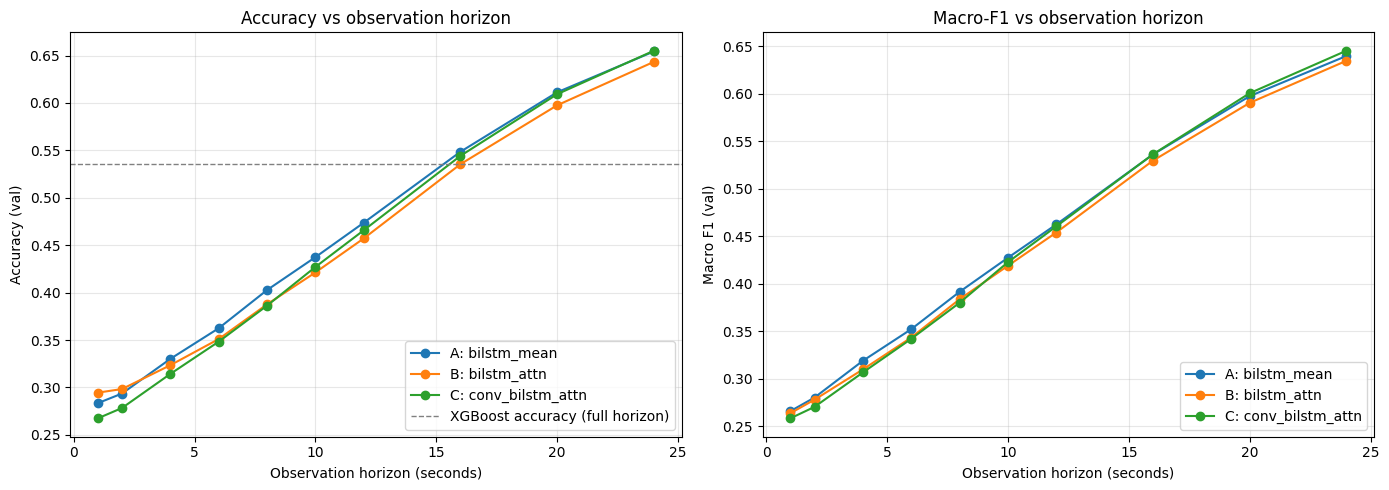

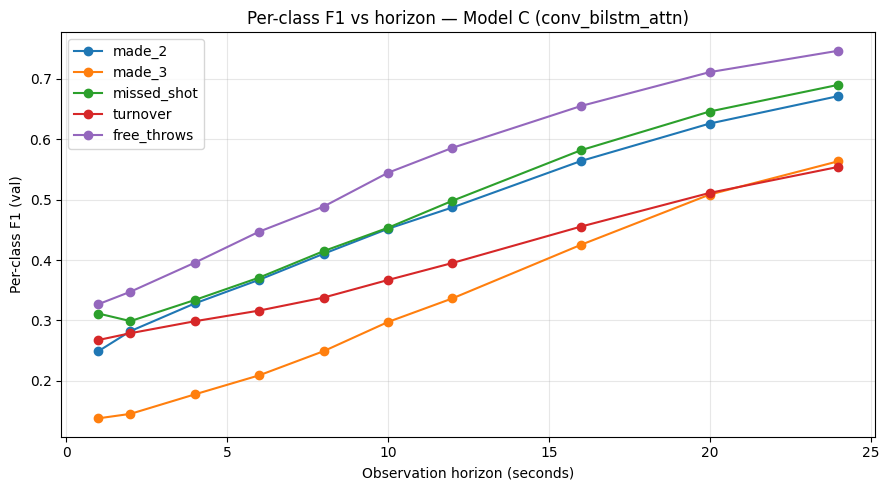


Horizon to reach P% of full-horizon macro-F1 (Model C):
  >=  80%  (0.5162):  horizon=16.0s  macroF1=0.5364  acc=0.5443
  >=  90%  (0.5808):  horizon=20.0s  macroF1=0.6006  acc=0.6093
  >=  95%  (0.6130):  horizon=24.0s  macroF1=0.6453  acc=0.6551
  >=  99%  (0.6388):  horizon=24.0s  macroF1=0.6453  acc=0.6551

Artifacts saved to: /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/artifacts


In [ ]:
import matplotlib.pyplot as plt

ART_DIR = REPO_DIR / 'artifacts'
ART_DIR.mkdir(parents=True, exist_ok=True)

# ---------- accuracy + macro-F1 vs horizon, all three models ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in RUN_SPECS:
    sub = df[df['model'] == label].sort_values('horizon_sec')
    axes[0].plot(sub['horizon_sec'], sub['accuracy'], marker='o', label=label)
    axes[1].plot(sub['horizon_sec'], sub['macro_f1'], marker='o', label=label)

# XGBoost frame-aggregate baseline (full-horizon) as dashed reference
for ax, bl_val, label in [(axes[0], 0.5354, 'XGBoost accuracy (full horizon)'),
                          (axes[1], None,   None)]:
    if bl_val is not None:
        ax.axhline(bl_val, color='grey', linestyle='--', linewidth=1, label=label)

axes[0].set_xlabel('Observation horizon (seconds)')
axes[0].set_ylabel('Accuracy (val)')
axes[0].set_title('Accuracy vs observation horizon')
axes[0].grid(True, alpha=0.3); axes[0].legend(loc='lower right')

axes[1].set_xlabel('Observation horizon (seconds)')
axes[1].set_ylabel('Macro F1 (val)')
axes[1].set_title('Macro-F1 vs observation horizon')
axes[1].grid(True, alpha=0.3); axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(ART_DIR / 'horizon_sweep_overall.png', dpi=120, bbox_inches='tight')
plt.show()

# ---------- per-class F1 vs horizon, winning model (C) ----------
sub_C = df[df['model'] == 'C: conv_bilstm_attn'].sort_values('horizon_sec')
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(NUM_CLASSES):
    col = f'f1_{INT_TO_LABEL[i]}'
    ax.plot(sub_C['horizon_sec'], sub_C[col], marker='o', label=INT_TO_LABEL[i])
ax.set_xlabel('Observation horizon (seconds)')
ax.set_ylabel('Per-class F1 (val)')
ax.set_title('Per-class F1 vs horizon — Model C (conv_bilstm_attn)')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(ART_DIR / 'horizon_sweep_per_class_C.png', dpi=120, bbox_inches='tight')
plt.show()

# ---------- summary table: earliest horizon to reach X% of full-horizon macro-F1 ----------
print('\nHorizon to reach P% of full-horizon macro-F1 (Model C):')
full_f1 = sub_C.loc[sub_C['horizon_sec'] == 24.0, 'macro_f1'].iloc[0]
for pct in (0.80, 0.90, 0.95, 0.99):
    threshold = pct * full_f1
    reached = sub_C[sub_C['macro_f1'] >= threshold].sort_values('horizon_sec')
    if len(reached):
        h = reached.iloc[0]
        print(f'  >= {pct*100:3.0f}%  ({threshold:.4f}):  '
              f'horizon={h["horizon_sec"]:>4.1f}s  '
              f'macroF1={h["macro_f1"]:.4f}  acc={h["accuracy"]:.4f}')
    else:
        print(f'  >= {pct*100:3.0f}%  ({threshold:.4f}):  never reached')

print(f'\nArtifacts saved to: {ART_DIR}')

# Seed Variance on Model C

In [ ]:
import json, time
from dataclasses import asdict, replace
import torch

from full_press_ml.training import TrainConfig, train, set_seed
from full_press_ml.models.sequence_models import build_model, count_parameters
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES
from full_press_ml.data.sequence_dataset import NUM_CLASSES

# Reuse: train_ds, val_ds, F_in, device, cfg, CHECKPOINT_DIR from Cell 18/21.

SEED_TO_RUN = {
    9:  'modelC_conv_bilstm_attn_v1',             # already trained in Cell 21
    17: 'modelC_conv_bilstm_attn_seed17',
    42: 'modelC_conv_bilstm_attn_seed42',
}

for seed, run_name in SEED_TO_RUN.items():
    best_path = CHECKPOINT_DIR / f'{run_name}_best.pt'
    if best_path.exists():
        print(f'[seed={seed:>3d}] {run_name}  already trained — skipping')
        continue

    print(f'\n======== training seed={seed} -> {run_name} ========')
    set_seed(seed)                                   # seed BEFORE model init
    model = build_model('conv_bilstm_attn', input_dim=F_in, num_classes=NUM_CLASSES)
    print(f'  params={count_parameters(model)}')

    cfg_seed = replace(cfg, seed=seed)
    (CHECKPOINT_DIR / f'{run_name}_config.json').write_text(
        json.dumps({'cfg': asdict(cfg_seed),
                    'model_type': 'conv_bilstm_attn',
                    'input_dim': F_in,
                    'num_classes': NUM_CLASSES,
                    'feature_names': ALL_MODEL_FEATURES},
                   indent=2, sort_keys=True)
    )

    t0 = time.time()
    result = train(
        model=model, train_ds=train_ds, val_ds=val_ds,
        cfg=cfg_seed, device=device,
        checkpoint_dir=CHECKPOINT_DIR, run_name=run_name,
    )
    print(f'[seed={seed:>3d}] wall={( time.time()-t0)/60:.1f}min  '
          f'best val macroF1={result["best_metric"]:.4f}  '
          f'(epoch {result["best_epoch"]})')

print('\nall seeds done')
for seed, run_name in SEED_TO_RUN.items():
    hist = json.loads((CHECKPOINT_DIR / f'{run_name}_history.json').read_text())
    best = max(hist, key=lambda e: (e['val_macro_f1'] or -1))
    print(f'  seed={seed:>3d}  run={run_name:<45s}  '
          f'best_epoch={best["epoch"]:>2d}  '
          f'val_macroF1={best["val_macro_f1"]:.4f}  '
          f'val_acc={best["val_acc"]:.4f}')

[seed=  9] modelC_conv_bilstm_attn_v1  already trained — skipping

======== training seed=17 -> modelC_conv_bilstm_attn_seed17 ========
  params={'total': 1010565, 'trainable': 1010565}
[train] run_name=modelC_conv_bilstm_attn_seed17
[train] train=72,495  val=24,281  batches/epoch=283  total_steps=14,150  warmup=707
[train] class_weights=[0.6697307229042053, 2.3522064685821533, 0.5800064206123352, 1.3454899787902832, 1.6276381015777588]
[train] device=cuda  precision=bf16
  step    100  epoch   0  batch   99/283  loss=1.5829  lr=4.29e-05
  step    200  epoch   0  batch  199/283  loss=1.3700  lr=8.53e-05
[epoch   0] train_loss=1.4992  val_loss=1.2414  val_acc=0.4569  val_macroF1=0.4432  lr=1.21e-04  time=20.7s
  new best val_macroF1=0.4432 -> saved _best.pt
  step    300  epoch   1  batch   16/283  loss=1.3217  lr=1.28e-04
  step    400  epoch   1  batch  116/283  loss=1.6016  lr=1.70e-04
  step    500  epoch   1  batch  216/283  loss=1.4828  lr=2.13e-04
[epoch   1] train_loss=1.2646  v

seed=  9: acc=0.6551  macroF1=0.6453
seed= 17: acc=0.6496  macroF1=0.6379
seed= 42: acc=0.6520  macroF1=0.6391

=== Full-horizon seed variance (Model C, n=3) ===
        accuracy: 0.6522 ± 0.0028   (seeds: ['0.6551', '0.6496', '0.6520'])
        macro_f1: 0.6408 ± 0.0040   (seeds: ['0.6453', '0.6379', '0.6391'])
       f1_made_2: 0.6646 ± 0.0070   (seeds: ['0.6716', '0.6575', '0.6646'])
       f1_made_3: 0.5464 ± 0.0198   (seeds: ['0.5637', '0.5508', '0.5248'])
  f1_missed_shot: 0.6867 ± 0.0031   (seeds: ['0.6902', '0.6853', '0.6846'])
     f1_turnover: 0.5633 ± 0.0084   (seeds: ['0.5543', '0.5646', '0.5710'])
  f1_free_throws: 0.7428 ± 0.0101   (seeds: ['0.7467', '0.7313', '0.7505'])


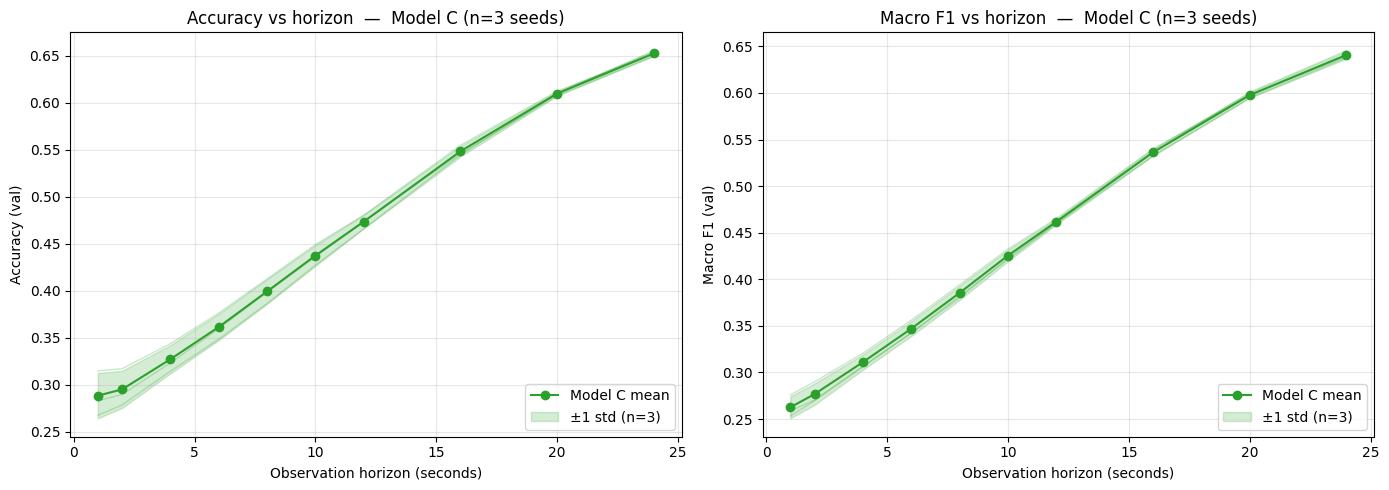


=== Reportable numbers (mean ± std) ===
  full-horizon accuracy: 0.6522 ± 0.0028
  full-horizon macro_f1: 0.6408 ± 0.0040
  16s-horizon macro_f1: 0.5362 ± 0.0037  (fraction of full: 0.837)


In [ ]:
#Horizon Sweep
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from full_press_ml.training import evaluate
from full_press_ml.data.sequence_dataset import collate_sequences, INT_TO_LABEL, NUM_CLASSES

# Reuse: SEED_TO_RUN, val_ds, val_loader (or rebuild), HORIZONS_SEC, HORIZONS_FRAMES, ART_DIR
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False,
                        num_workers=2, collate_fn=collate_sequences, pin_memory=True)

def load_model(run_name):
    m = build_model('conv_bilstm_attn', input_dim=F_in, num_classes=NUM_CLASSES).to(device)
    ckpt = torch.load(CHECKPOINT_DIR / f'{run_name}_best.pt', map_location=device, weights_only=False)
    m.load_state_dict(ckpt['model']); m.eval()
    return m

# ---------- full-horizon per-seed + horizon sweep per-seed ----------
full_rows, sweep_rows = [], []
for seed, run_name in SEED_TO_RUN.items():
    model = load_model(run_name)
    m = evaluate(model=model, loader=val_loader, criterion=nn.CrossEntropyLoss(),
                 device=device, precision='bf16')
    full_rows.append({
        'seed': seed, 'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'],
        **{f'f1_{INT_TO_LABEL[i]}': m['per_class_f1'][i] for i in range(NUM_CLASSES)},
    })
    for h_sec, h_frames in zip(HORIZONS_SEC, HORIZONS_FRAMES):
        mh = evaluate(model=model, loader=val_loader, criterion=nn.CrossEntropyLoss(),
                      device=device, horizon_frames=h_frames, precision='bf16')
        sweep_rows.append({
            'seed': seed, 'horizon_sec': h_sec, 'horizon_frames': h_frames,
            'accuracy': mh['accuracy'], 'macro_f1': mh['macro_f1'],
            **{f'f1_{INT_TO_LABEL[i]}': mh['per_class_f1'][i] for i in range(NUM_CLASSES)},
        })
    print(f'seed={seed:>3d}: acc={m["accuracy"]:.4f}  macroF1={m["macro_f1"]:.4f}')

full_df  = pd.DataFrame(full_rows).set_index('seed')
sweep_df = pd.DataFrame(sweep_rows)

# ---------- summary: mean ± sample std across seeds ----------
print('\n=== Full-horizon seed variance (Model C, n=3) ===')
mean = full_df.mean(axis=0); std = full_df.std(axis=0, ddof=1)
for col in ['accuracy', 'macro_f1'] + [f'f1_{INT_TO_LABEL[i]}' for i in range(NUM_CLASSES)]:
    vals = full_df[col].tolist()
    print(f'  {col:>14s}: {mean[col]:.4f} ± {std[col]:.4f}   '
          f'(seeds: {[f"{v:.4f}" for v in vals]})')

# ---------- save aggregated results ----------
full_df.to_csv(CHECKPOINT_DIR / 'modelC_seed_variance_full.csv')
sweep_df.to_csv(CHECKPOINT_DIR / 'modelC_seed_variance_sweep.csv', index=False)
(CHECKPOINT_DIR / 'modelC_seed_variance_summary.json').write_text(json.dumps({
    'n_seeds': len(SEED_TO_RUN),
    'seeds': list(SEED_TO_RUN.keys()),
    'full_mean': mean.to_dict(),
    'full_std':  std.to_dict(),
}, indent=2, default=float))

# ---------- plot: macro-F1 and accuracy vs horizon with ±1 std bands ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, ax, ttl in [('accuracy', axes[0], 'Accuracy'), ('macro_f1', axes[1], 'Macro F1')]:
    grp = sweep_df.groupby('horizon_sec')[col]
    m_ = grp.mean(); s_ = grp.std(ddof=1)
    ax.plot(m_.index, m_.values, marker='o', color='C2', label='Model C mean')
    ax.fill_between(m_.index, m_.values - s_.values, m_.values + s_.values,
                    alpha=0.2, color='C2', label='±1 std (n=3)')
    # also overlay the individual seeds as thin lines
    for seed in SEED_TO_RUN:
        sub = sweep_df[sweep_df['seed'] == seed].sort_values('horizon_sec')
        ax.plot(sub['horizon_sec'], sub[col], color='C2', alpha=0.25, linewidth=1)
    ax.set_xlabel('Observation horizon (seconds)')
    ax.set_ylabel(f'{ttl} (val)')
    ax.set_title(f'{ttl} vs horizon  —  Model C (n=3 seeds)')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(ART_DIR / 'seed_variance_horizon_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# ---------- summary claim numbers ----------
print('\n=== Reportable numbers (mean ± std) ===')
for col in ('accuracy', 'macro_f1'):
    full_v = sweep_df[sweep_df['horizon_sec'] == 24.0][col]
    print(f'  full-horizon {col}: {full_v.mean():.4f} ± {full_v.std(ddof=1):.4f}')
at16 = sweep_df[sweep_df['horizon_sec'] == 16.0]
print(f'  16s-horizon macro_f1: {at16["macro_f1"].mean():.4f} ± {at16["macro_f1"].std(ddof=1):.4f}  '
      f'(fraction of full: {at16["macro_f1"].mean() / sweep_df[sweep_df["horizon_sec"] == 24.0]["macro_f1"].mean():.3f})')

##Test Set Evaluation

In [ ]:
# ============================================================================
# Cell 27a (v3) — Probe pack_summary and Dataset constructor
# ============================================================================
import json, inspect
from pathlib import Path

from full_press_ml.data.sequence_dataset import PossessionSequenceDataset

SEQ_DIR = Path("/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/data/processed/full/sequences")

print("PossessionSequenceDataset.__init__ signature:")
print(" ", inspect.signature(PossessionSequenceDataset.__init__))

with (SEQ_DIR / "pack_summary.json").open() as f:
    pack_summary = json.load(f)

print("\npack_summary top-level keys:", list(pack_summary.keys()))
for k, v in pack_summary.items():
    if isinstance(v, list):
        print(f"  {k}: list len={len(v)}  head={v[:5]}")
    elif isinstance(v, dict):
        print(f"  {k}: dict keys={list(v.keys())[:8]}")
    else:
        print(f"  {k}: {v}")

PossessionSequenceDataset.__init__ signature:
  (self, sequences_dir: 'Path', split: 'str', feature_names: 'Sequence[str]', scaler_stats: 'dict | None' = None, max_len: 'int | None' = 300)

pack_summary top-level keys: ['test', 'train', 'val']
  test: dict keys=['label_counts_int', 'length_max', 'length_mean', 'length_min', 'length_p50', 'length_p95', 'num_features', 'num_possessions']
  train: dict keys=['label_counts_int', 'length_max', 'length_mean', 'length_min', 'length_p50', 'length_p95', 'num_features', 'num_possessions']
  val: dict keys=['label_counts_int', 'length_max', 'length_mean', 'length_min', 'length_p50', 'length_p95', 'num_features', 'num_possessions']


Using CKPT_DIR: /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/checkpoints
feature_names: 33 features  (first 5: ['ball_x', 'ball_y', 'ball_z', 'shot_clock', 'game_clock'])
train_X shape: (19615982, 33)  ✓ matches feature_names
features without scaler (binary, pass-through): ['ball_is_in_frontcourt', 'ball_height_on_floor', 'ball_height_dribble', 'ball_height_pass', 'ball_height_in_flight', 'shot_clock_missing']

test possessions: 23538
test class counts: {'made_2': 7002, 'made_3': 2055, 'missed_shot': 8064, 'turnover': 3514, 'free_throws': 2903}

evaluate() params: ['model', 'loader', 'criterion', 'device', 'horizon_frames', 'precision']

=== seed 9 (modelC_conv_bilstm_attn_v1) ===
  full: acc=0.6326  macroF1=0.6259
  h= 25 ( 2.0s): acc=0.2919  macroF1=0.2888
  h= 50 ( 4.0s): acc=0.3289  macroF1=0.3249
  h= 75 ( 6.0s): acc=0.3615  macroF1=0.3581
  h=100 ( 8.0s): acc=0.3967  macroF1=0.3928
  h=150 (12.0s): acc=0.4718  macroF1=0.4678
  h=200 (16.0s): acc=0.5361  macroF1=

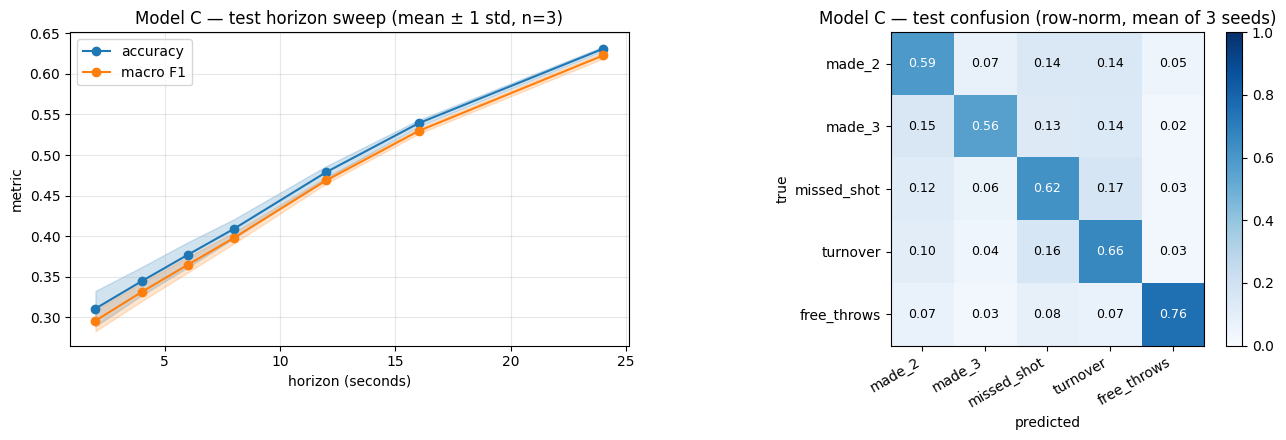

  plot: /content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML/checkpoints/modelC_test_horizon_and_confusion.png


In [ ]:
# ============================================================================
# Cell 27 — Test-set evaluation on Model C (seeds 9, 17, 42) — FINAL
# ============================================================================
import json
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from full_press_ml.data.sequence_dataset import (
    PossessionSequenceDataset,
    collate_sequences,
    LABEL_TO_INT,
    NUM_CLASSES,
)
from full_press_ml.features.frame_features import ALL_MODEL_FEATURES
from full_press_ml.models.sequence_models import build_model
from full_press_ml.training.loops import evaluate

# --- paths (all under Full-Press-ML/) ---
FP_ROOT       = Path("/content/drive/MyDrive/Academic/CSCI 567/Project/Full-Press-ML")
PROCESSED_DIR = FP_ROOT / "data/processed/full"
SEQ_DIR       = PROCESSED_DIR / "sequences"

# checkpoints: auto-detect which dir your runs live in
CKPT_CANDIDATES = [
    FP_ROOT / "checkpoints",
    FP_ROOT.parent / "checkpoints",  # /Project/checkpoints
]
CKPT_DIR = next((p for p in CKPT_CANDIDATES if p.exists()), None)
assert CKPT_DIR is not None, f"Couldn't find checkpoints in: {CKPT_CANDIDATES}"
print(f"Using CKPT_DIR: {CKPT_DIR}")

SEEDS = [9, 17, 42]
RUN_NAMES = {
    9:  "modelC_conv_bilstm_attn_v1",
    17: "modelC_conv_bilstm_attn_seed17",
    42: "modelC_conv_bilstm_attn_seed42",
}
MODEL_TYPE = "conv_bilstm_attn"
HORIZONS   = [25, 50, 75, 100, 150, 200, 300]  # 2,4,6,8,12,16,24 s @ 12.5 Hz

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- load scaler (per-feature dict) and ordered feature names ---
with (PROCESSED_DIR / "feature_scaler.json").open() as f:
    scaler_stats = json.load(f)
feature_names = list(ALL_MODEL_FEATURES)
print(f"feature_names: {len(feature_names)} features  (first 5: {feature_names[:5]})")

# sanity: X column count must match feature_names length
train_X = np.load(SEQ_DIR / "train_X.npy", mmap_mode="r")
assert train_X.shape[1] == len(feature_names), (
    f"X has {train_X.shape[1]} cols but ALL_MODEL_FEATURES has {len(feature_names)}"
)
print(f"train_X shape: {train_X.shape}  ✓ matches feature_names")
del train_X

# sanity: every continuous feature in scaler_stats is present in feature_names
missing = [k for k in scaler_stats.keys() if k not in feature_names]
if missing:
    print(f"WARN: scaler has features not in ALL_MODEL_FEATURES: {missing}")
no_scale = [f for f in feature_names if f not in scaler_stats]
print(f"features without scaler (binary, pass-through): {no_scale}")

# --- test dataset ---
test_ds = PossessionSequenceDataset(
    sequences_dir=SEQ_DIR,
    split="test",
    feature_names=feature_names,
    scaler_stats=scaler_stats,
    max_len=300,
)
print(f"\ntest possessions: {len(test_ds)}")
test_loader = DataLoader(
    test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True,
    collate_fn=lambda b: collate_sequences(b, fixed_max_len=None),
)

int_to_label = {v: k for k, v in LABEL_TO_INT.items()}
test_labels = np.load(SEQ_DIR / "test_labels.npy")
print("test class counts:", {int_to_label[i]: int((test_labels == i).sum()) for i in range(NUM_CLASSES)})

# --- evaluate() signature check (in case arg names differ) ---
eval_sig = inspect.signature(evaluate)
print(f"\nevaluate() params: {list(eval_sig.parameters)}")

def run_eval(model, horizon):
    kwargs = dict(model=model, loader=test_loader, device=device)
    if "criterion" in eval_sig.parameters:
        kwargs["criterion"] = torch.nn.CrossEntropyLoss()
    if "horizon_frames" in eval_sig.parameters:
        kwargs["horizon_frames"] = horizon
    elif "horizon" in eval_sig.parameters:
        kwargs["horizon"] = horizon
    if "precision" in eval_sig.parameters:
        kwargs["precision"] = "bf16"
    return evaluate(**kwargs)

# Replace the existing load_model() with this and rerun Cell 27
def load_model(run_name):
    ckpt_path = CKPT_DIR / f"{run_name}_best.pt"
    assert ckpt_path.exists(), f"missing checkpoint: {ckpt_path}"
    model = build_model(MODEL_TYPE, input_dim=len(feature_names), num_classes=NUM_CLASSES)
    state = torch.load(ckpt_path, map_location=device)
    # training harness wraps the weights under one of these keys
    for k in ("model", "model_state_dict", "state_dict"):
        if isinstance(state, dict) and k in state and isinstance(state[k], dict):
            state = state[k]
            break
    model.load_state_dict(state)
    model.to(device).eval()
    return model

# --- evaluate each seed at full horizon + sweep ---
per_seed_full = {}
per_seed_sweep = {s: [] for s in SEEDS}
per_seed_confusion = {}

for seed in SEEDS:
    run_name = RUN_NAMES[seed]
    print(f"\n=== seed {seed} ({run_name}) ===")
    model = load_model(run_name)

    full_m = run_eval(model, None)
    per_seed_full[seed] = full_m
    per_seed_confusion[seed] = full_m["confusion_matrix"]
    print(f"  full: acc={full_m['accuracy']:.4f}  macroF1={full_m['macro_f1']:.4f}")

    for h in HORIZONS:
        m = run_eval(model, h)
        per_seed_sweep[seed].append({
            "horizon_frames": h,
            "horizon_seconds": h / 12.5,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            **{f"f1_{int_to_label[i]}": m["per_class_f1"][i] for i in range(NUM_CLASSES)},
        })
        print(f"  h={h:3d} ({h/12.5:4.1f}s): acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}")

    del model
    torch.cuda.empty_cache()

# --- aggregate full-horizon ---
def _mean_std(vals):
    arr = np.array(vals, dtype=np.float64)
    return float(arr.mean()), float(arr.std(ddof=1))

full_accs = [per_seed_full[s]["accuracy"] for s in SEEDS]
full_f1s  = [per_seed_full[s]["macro_f1"] for s in SEEDS]
per_class_f1 = {
    int_to_label[i]: [per_seed_full[s]["per_class_f1"][i] for s in SEEDS]
    for i in range(NUM_CLASSES)
}

test_full_summary = {
    "n_seeds": len(SEEDS),
    "seeds": SEEDS,
    "accuracy_mean": _mean_std(full_accs)[0],
    "accuracy_std":  _mean_std(full_accs)[1],
    "macro_f1_mean": _mean_std(full_f1s)[0],
    "macro_f1_std":  _mean_std(full_f1s)[1],
    "per_class_f1_mean": {k: _mean_std(v)[0] for k, v in per_class_f1.items()},
    "per_class_f1_std":  {k: _mean_std(v)[1] for k, v in per_class_f1.items()},
    "per_seed": {
        str(s): {
            "accuracy": per_seed_full[s]["accuracy"],
            "macro_f1": per_seed_full[s]["macro_f1"],
            "per_class_f1": {int_to_label[i]: per_seed_full[s]["per_class_f1"][i] for i in range(NUM_CLASSES)},
        } for s in SEEDS
    },
}

conf_stack = np.stack([np.array(per_seed_confusion[s], dtype=np.float64) for s in SEEDS], axis=0)
conf_mean  = conf_stack.mean(axis=0)
conf_mean_rownorm = conf_mean / np.clip(conf_mean.sum(axis=1, keepdims=True), 1, None)

# --- aggregate horizon sweep ---
sweep_rows = []
for idx, h in enumerate(HORIZONS):
    row = {"horizon_frames": h, "horizon_seconds": h / 12.5}
    for metric in ["accuracy", "macro_f1"] + [f"f1_{int_to_label[i]}" for i in range(NUM_CLASSES)]:
        vals = [per_seed_sweep[s][idx][metric] for s in SEEDS]
        m, sd = _mean_std(vals)
        row[f"{metric}_mean"] = m
        row[f"{metric}_std"]  = sd
    sweep_rows.append(row)
sweep_df = pd.DataFrame(sweep_rows)

# --- save artifacts (next to seed-variance files) ---
OUT_DIR = CKPT_DIR
with (OUT_DIR / "modelC_test_seed_variance_full.json").open("w") as f:
    json.dump(test_full_summary, f, indent=2)
sweep_df.to_csv(OUT_DIR / "modelC_test_seed_variance_sweep.csv", index=False)
np.save(OUT_DIR / "modelC_test_confusion_mean.npy", conf_mean)
print(f"\nSaved:")
print(f"  {OUT_DIR/'modelC_test_seed_variance_full.json'}")
print(f"  {OUT_DIR/'modelC_test_seed_variance_sweep.csv'}")
print(f"  {OUT_DIR/'modelC_test_confusion_mean.npy'}")

# --- headline ---
print("\n=== TEST-SET Reportable numbers (Model C, n=3 seeds) ===")
print(f"  full-horizon accuracy : {test_full_summary['accuracy_mean']:.4f} ± {test_full_summary['accuracy_std']:.4f}")
print(f"  full-horizon macro_f1 : {test_full_summary['macro_f1_mean']:.4f} ± {test_full_summary['macro_f1_std']:.4f}")
for cls in ["made_2", "made_3", "missed_shot", "turnover", "free_throws"]:
    m  = test_full_summary["per_class_f1_mean"][cls]
    sd = test_full_summary["per_class_f1_std"][cls]
    print(f"  f1_{cls:<12s}: {m:.4f} ± {sd:.4f}")
row16 = sweep_df[sweep_df["horizon_frames"] == 200].iloc[0]
print(f"  16s-horizon macro_f1  : {row16['macro_f1_mean']:.4f} ± {row16['macro_f1_std']:.4f}"
      f"  (fraction of full: {row16['macro_f1_mean']/test_full_summary['macro_f1_mean']:.3f})")

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
x = sweep_df["horizon_seconds"].values
for metric, label, color in [("accuracy", "accuracy", "C0"), ("macro_f1", "macro F1", "C1")]:
    m  = sweep_df[f"{metric}_mean"].values
    sd = sweep_df[f"{metric}_std"].values
    ax.plot(x, m, marker="o", color=color, label=label)
    ax.fill_between(x, m - sd, m + sd, alpha=0.20, color=color)
ax.set_xlabel("horizon (seconds)"); ax.set_ylabel("metric")
ax.set_title("Model C — test horizon sweep (mean ± 1 std, n=3)")
ax.grid(True, alpha=0.3); ax.legend()

ax = axes[1]
labels_in_order = [int_to_label[i] for i in range(NUM_CLASSES)]
im = ax.imshow(conf_mean_rownorm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(labels_in_order, rotation=30, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(labels_in_order)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Model C — test confusion (row-norm, mean of 3 seeds)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{conf_mean_rownorm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if conf_mean_rownorm[i, j] > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plot_path = OUT_DIR / "modelC_test_horizon_and_confusion.png"
plt.savefig(plot_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"  plot: {plot_path}")

Can you generate a 5 slide presentation with a USC viterbi theme and colors about this experiment. Include 1. Dataset and problem 2. Idea and design choices for LSTM 3. LSTM Architectures tried 4. Results 5. Discussion